# 03 — EDA (Análisis Exploratorio de Datos)

**Objetivo:** entender el negocio con datos para tomar decisiones informadas sobre el modelado.

El propósito de este notebook es responder preguntas concretas sobre el comportamiento del negocio:

- ¿Cuál es el patrón de ventas diarias? ¿Hay estacionalidad semanal, mensual, por temporada?
- ¿Qué variables correlacionan con las ventas? ¿Temperatura, festivos, día de la semana?
- ¿Cómo se comportan las reservas respecto a los tickets reales?
- ¿Qué artículos concentran el 80% de la facturación?
- ¿Hay diferencias relevantes entre turno de comida y cena?

Las respuestas a estas preguntas definen qué features entran al modelo y con qué forma.


*Arquitectura Medallion: Bronze → Silver → **Gold***

### 0. Setup

Imports, rutas, carga de los parquets de Silver. Una sola celda de configuración compartida.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Rutas del proyecto ────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

for p in [str(PROJECT_ROOT), str(PROJECT_ROOT / 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

DATA_DIR    = PROJECT_ROOT / 'data'
BRONZE_SNAP = DATA_DIR / 'bronze' / 'snapshots'
SILVER_SNAP = DATA_DIR / 'silver' / 'snapshots'
GOLD_DIR    = DATA_DIR / 'gold'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures' / 'eda'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root : {PROJECT_ROOT}')
print(f'Bronze snaps : {BRONZE_SNAP}')
print(f'Silver snaps : {SILVER_SNAP}')
print(f'Gold dir     : {GOLD_DIR}')
print(f'Figures dir  : {FIGURES_DIR}')

Project root : /Users/laura/TFM-Hosteleria-AI
Bronze snaps : /Users/laura/TFM-Hosteleria-AI/data/bronze/snapshots
Silver snaps : /Users/laura/TFM-Hosteleria-AI/data/silver/snapshots
Gold dir     : /Users/laura/TFM-Hosteleria-AI/data/gold
Figures dir  : /Users/laura/TFM-Hosteleria-AI/results/figures/eda


### 1. Visión general de los datos Silver
Tabla resumen de todos los datasets: filas, columnas, cobertura temporal. El equivalente al `audit_dataset` de la depuración, pero aquí como punto de partida descriptivo, no como diagnóstico de calidad (eso ya está hecho).

In [2]:
# ── Carga desde Silver ────────────────────────────────────────────────────────
df_tickets       = pd.read_parquet(SILVER_SNAP / 'tickets_silver.parquet')
df_ventas        = pd.read_parquet(SILVER_SNAP / 'ventas_silver.parquet')
df_reservas      = pd.read_parquet(SILVER_SNAP / 'reservas_silver.parquet')
df_tips          = pd.read_parquet(SILVER_SNAP / 'tips_silver.parquet')
df_artic         = pd.read_parquet(SILVER_SNAP / 'articulos_silver.parquet')
df_depart        = pd.read_parquet(SILVER_SNAP / 'departamentos_silver.parquet')
df_menu          = pd.read_parquet(SILVER_SNAP / 'menu_silver.parquet')
df_festivos      = pd.read_parquet(SILVER_SNAP / 'festivos_silver.parquet')
df_eventos       = pd.read_parquet(SILVER_SNAP / 'eventos_silver.parquet')
df_meteo_diaria  = pd.read_parquet(SILVER_SNAP / 'meteo_diaria_silver.parquet')
df_meteo_horaria = pd.read_parquet(SILVER_SNAP / 'meteo_horaria_silver.parquet')
df_facturas      = pd.read_parquet(SILVER_SNAP / 'facturas_silver.parquet')
# df_total_articles = pd.read_parquet(SILVER_SNAP / 'total_articles_silver.parquet')

print('Datasets cargados desde Silver:')
for nombre, df in {
    'tickets': df_tickets, 'ventas': df_ventas, 'reservas': df_reservas,
    'tips': df_tips, 'articulos': df_artic, 'departamentos': df_depart,
    'menu': df_menu, 'festivos': df_festivos, 'eventos': df_eventos,
    'meteo_diaria': df_meteo_diaria, 'meteo_horaria': df_meteo_horaria,
    'facturas': df_facturas,
    # 'total_articles': df_total_articles
}.items():
    print(f'  ✓  {nombre:<20} {len(df):>6,} filas  x  {len(df.columns)} columnas')

Datasets cargados desde Silver:
  ✓  tickets               6,709 filas  x  14 columnas
  ✓  ventas                5,532 filas  x  14 columnas
  ✓  reservas             21,289 filas  x  21 columnas
  ✓  tips                  1,697 filas  x  12 columnas
  ✓  articulos               405 filas  x  4 columnas
  ✓  departamentos            23 filas  x  3 columnas
  ✓  menu                    405 filas  x  3 columnas
  ✓  festivos                 56 filas  x  5 columnas
  ✓  eventos                  48 filas  x  20 columnas
  ✓  meteo_diaria          1,286 filas  x  10 columnas
  ✓  meteo_horaria        30,864 filas  x  4 columnas
  ✓  facturas                 72 filas  x  18 columnas


In [3]:
def audit_dataset(nombre, df, col_fecha=None):
    fecha_min = pd.NaT
    fecha_max = pd.NaT
    if col_fecha is not None and col_fecha in df.columns:
        col = pd.to_datetime(df[col_fecha], errors='coerce')
        fecha_min = col.min()
        fecha_max = col.max()
    return {
        'dataset':            nombre,
        'filas':              len(df),
        'columnas':           len(df.columns),
        'nulos_pct_max':      round(df.isnull().mean().max() * 100, 2),
        'duplicados_exactos': int(df.duplicated().sum()),
        'fecha_min':          fecha_min,
        'fecha_max':          fecha_max,
    }

auditoria = pd.DataFrame([
    audit_dataset('tickets',       df_tickets,       col_fecha='date'),
    audit_dataset('ventas',        df_ventas,        col_fecha='report_start'),
    audit_dataset('reservas',      df_reservas,      col_fecha='reservation_datetime'),
    audit_dataset('tips',          df_tips,          col_fecha=None),
    audit_dataset('articulos',     df_artic,         col_fecha=None),  # catálogo estático
    audit_dataset('departamentos', df_depart,        col_fecha=None),  # catálogo estático
    audit_dataset('menu',          df_menu,          col_fecha=None),  # catálogo estático
    audit_dataset('festivos',      df_festivos,      col_fecha='fecha'),
    audit_dataset('eventos',       df_eventos,       col_fecha='fecha_inicio'),
    audit_dataset('meteo_diaria',  df_meteo_diaria,  col_fecha='date'),
    audit_dataset('meteo_horaria', df_meteo_horaria, col_fecha='datetime'),
    audit_dataset('facturas',      df_facturas,      col_fecha='fecha'), # dataset nuevo
    # audit_dataset('total_articles',      df_total_articles,      col_fecha='fecha') excluido: agregado global sin granularidad diaria,
    # no aporta al EDA orientado a series temporales. Cargar explícitamente si se necesita.
])

display(auditoria)

,dataset,filas,columnas,nulos_pct_max,duplicados_exactos,fecha_min,fecha_max
0,tickets,6709,14,0.00,0,2025-10-02 00:00:00,2026-07-09 00:00:00
1,ventas,5532,14,0.00,0,2025-10-01 00:00:00,2026-07-06 00:00:00
2,reservas,21289,21,6.78,0,2022-11-10 13:45:00,2026-07-08 21:15:00
3,tips,1697,12,0.00,0,NaT,NaT
4,articulos,405,4,0.00,0,NaT,NaT
5,departamentos,23,3,0.00,0,NaT,NaT
6,menu,405,3,0.00,0,NaT,NaT
7,festivos,56,5,0.00,0,2023-01-01 00:00:00,2026-05-02 00:00:00
8,eventos,48,20,0.00,0,2025-10-10 00:00:00,2026-09-16 00:00:00
9,meteo_diaria,1286,10,0.00,0,2023-01-01 00:00:00,2026-07-09 00:00:00


### 2. Análisis de la variable objetivo: ingresos diarios
La serie temporal de facturación agregada por día es el núcleo del TFM. Todo lo demás es contexto explicativo de esta variable.

- Evolución temporal de facturación diaria (tickets + ventas)
- Distribución del importe por ticket
- Detección visual de outliers y comportamientos anómalos
- Patrón por día de la semana y por turno

La facturación diaria es la variable que el modelo deberá predecir.

En esta sección construimos la serie temporal agregada, analizamos su distribución, identificamos patrones temporales y detectamos anomalías.

Las fuentes utilizadas son `df_tickets` (un registro por ticket) y `df_ventas` (un registro por artículo vendido). Ambas cubren el período 2025-10-01 / 2026-07-09.

#### 2.1. Construcción de la serie diaria

In [4]:
# Agregamos df_tickets a nivel diario.
# document_total es el importe total del ticket — es la variable objetivo.
# Usamos 'date' como columna de fecha (ya depurada en Silver).

ingresos_diarios = (
    df_tickets
    .groupby('date')
    .agg(
        num_tickets      = ('document_id',    'nunique'),
        facturacion      = ('document_total', 'sum'),
        ticket_medio     = ('document_total', 'mean'),
        ticket_mediano   = ('document_total', 'median'),
    )
    .reset_index()
    .rename(columns={'date': 'fecha'})
    .sort_values('fecha')
)

print(f"Período: {ingresos_diarios['fecha'].min()}  →  {ingresos_diarios['fecha'].max()}")
print(f"Días con actividad : {len(ingresos_diarios)}")
print(f"Días totales en período: {(ingresos_diarios['fecha'].max() - ingresos_diarios['fecha'].min()).days + 1}")
print(f"\nEstadísticas de facturación diaria:")
display(ingresos_diarios['facturacion'].describe().to_frame().T.round(2))

Período: 2025-10-02 00:00:00  →  2026-07-09 00:00:00
Días con actividad : 242
Días totales en período: 281

Estadísticas de facturación diaria:


,count,mean,std,min,25%,50%,75%,max
facturacion,242.0,2799.55,1346.66,637.9,1746.55,2440.93,3816.29,6785.2


La facturación diaria media es de **2.799€** (mediana 2.441€), con una desviación típica de 1.346€ — un coeficiente de variación del 48%, que indica alta dispersión. 

El rango va de 638€ a 6.785€. 

La diferencia entre media y mediana (358€) apunta a una distribución asimétrica hacia la derecha, con días de facturación excepcionalmente alta que tiran de la media hacia arriba.

#### 2.2. Días sin actividad

In [5]:
# Detectamos días del período sin ningún ticket registrado.
# Pueden ser cierres, festivos o huecos en los datos — hay que distinguirlos.

rango_completo = pd.date_range(
    start=ingresos_diarios['fecha'].min(),
    end=ingresos_diarios['fecha'].max(),
    freq='D'
)

dias_sin_actividad = rango_completo.difference(pd.to_datetime(ingresos_diarios['fecha']))

print(f"Días sin actividad: {len(dias_sin_actividad)}")
print()

# Cruzamos con festivos para clasificar cada ausencia
fechas_festivos = pd.to_datetime(df_festivos['fecha'])

for d in sorted(dias_sin_actividad):
    es_festivo = d in fechas_festivos.values
    dia_semana = d.day_name()
    nombre     = df_festivos.loc[pd.to_datetime(df_festivos['fecha']) == d, 'festivo_nombre'].values
    etiqueta   = nombre[0] if len(nombre) > 0 else ('festivo s/n' if es_festivo else 'cierre operativo')
    print(f"  {d.date()}  {dia_semana:<12}  {etiqueta}")

Días sin actividad: 39

  2025-10-06  Monday        cierre operativo
  2025-10-14  Tuesday       cierre operativo
  2025-10-20  Monday        cierre operativo
  2025-10-27  Monday        cierre operativo
  2025-11-03  Monday        cierre operativo
  2025-11-10  Monday        Ntra. Sra. de la Almudena (festivo local Madrid capital, trasladado)
  2025-11-17  Monday        cierre operativo
  2025-11-24  Monday        cierre operativo
  2025-12-01  Monday        cierre operativo
  2025-12-09  Tuesday       cierre operativo
  2025-12-15  Monday        cierre operativo
  2025-12-29  Monday        cierre operativo
  2026-01-07  Wednesday     cierre operativo
  2026-01-12  Monday        cierre operativo
  2026-01-19  Monday        cierre operativo
  2026-01-26  Monday        cierre operativo
  2026-02-02  Monday        cierre operativo
  2026-02-09  Monday        cierre operativo
  2026-02-16  Monday        cierre operativo
  2026-02-23  Monday        cierre operativo
  2026-03-02  Monday    

El restaurante opera 242 de los 281 días del período (oct-25 / jul-09-26), lo que supone un 86% de días con actividad. 

Los 39 días restantes son **cierres operativos sistemáticos**, no huecos de datos: 35 de ellos caen en lunes, lo que confirma que el lunes es el día de cierre habitual del
establecimiento. Las cuatro excepciones (un martes en octubre, un martes en diciembre, un miércoles en enero y una ausencia puntual) requieren
verificación con el negocio — pueden ser cierres por vacaciones o festivos internos no documentados. 

Este patrón de cierre **debe incorporarse al modelo como variable binaria** (`es_lunes_cierre`) para evitar que el modelo intente predecir facturación en días que estructuralmente no abren.

#### 2.3. Evolución temporal

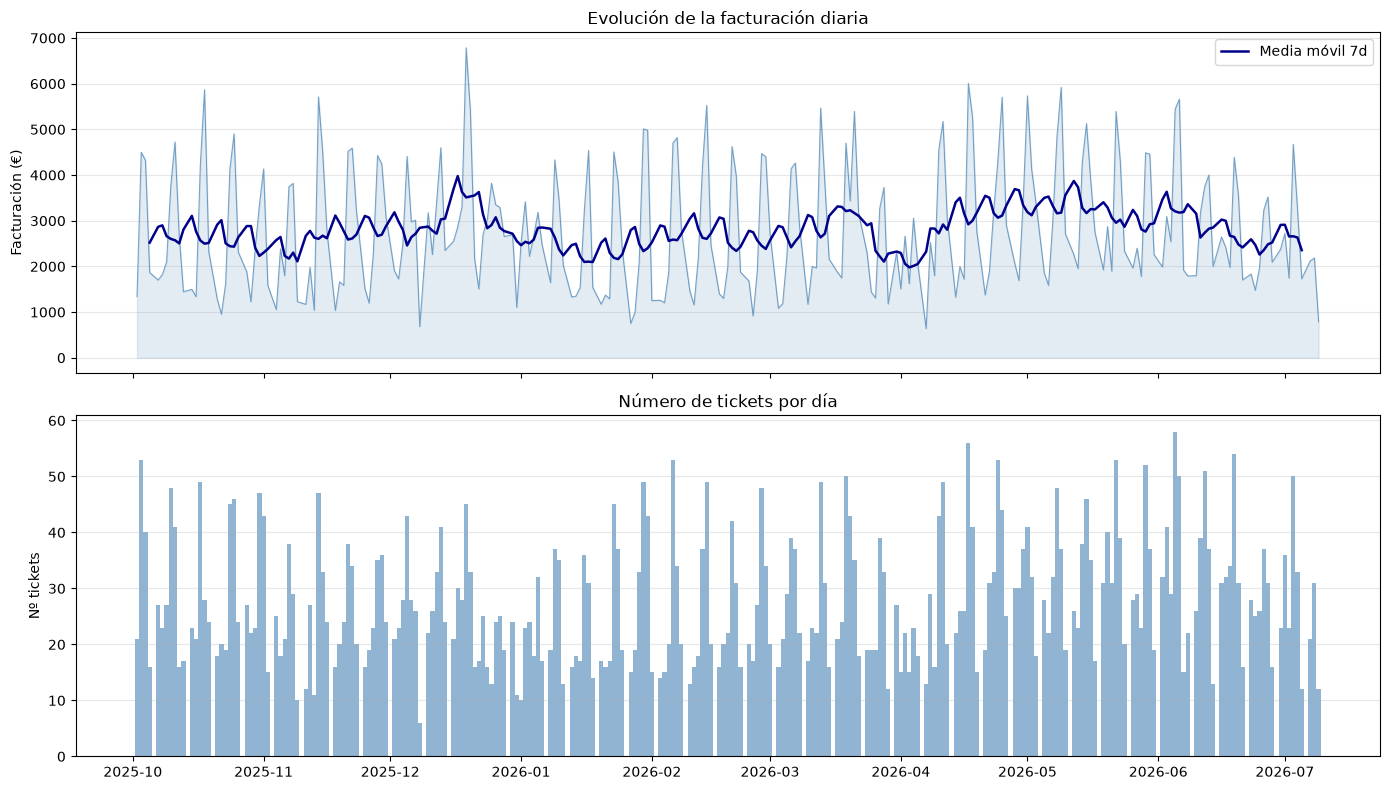

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel superior: facturación diaria
axes[0].plot(ingresos_diarios['fecha'], ingresos_diarios['facturacion'],
             color='steelblue', linewidth=0.8, alpha=0.7)
axes[0].fill_between(ingresos_diarios['fecha'], ingresos_diarios['facturacion'],
                     alpha=0.15, color='steelblue')

# Media móvil 7 días para ver tendencia sin ruido semanal
media_movil = ingresos_diarios['facturacion'].rolling(7, center=True).mean()
axes[0].plot(ingresos_diarios['fecha'], media_movil,
             color='darkblue', linewidth=1.8, label='Media móvil 7d')

axes[0].set_ylabel('Facturación (€)')
axes[0].set_title('Evolución de la facturación diaria')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Panel inferior: número de tickets
axes[1].bar(ingresos_diarios['fecha'], ingresos_diarios['num_tickets'],
            color='steelblue', alpha=0.6, width=1)
axes[1].set_ylabel('Nº tickets')
axes[1].set_title('Número de tickets por día')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'evolucion_facturacion_diaria.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
df_tickets['document_total'].value_counts().sort_index()

document_total
1.00        1
2.00        6
2.35       38
2.50        1
2.95       13
           ..
1035.00     1
1170.00     1
1344.00     1
1435.00     1
3821.65     1
Name: count, Length: 2669, dtype: int64

#### Patrón por día de la semana

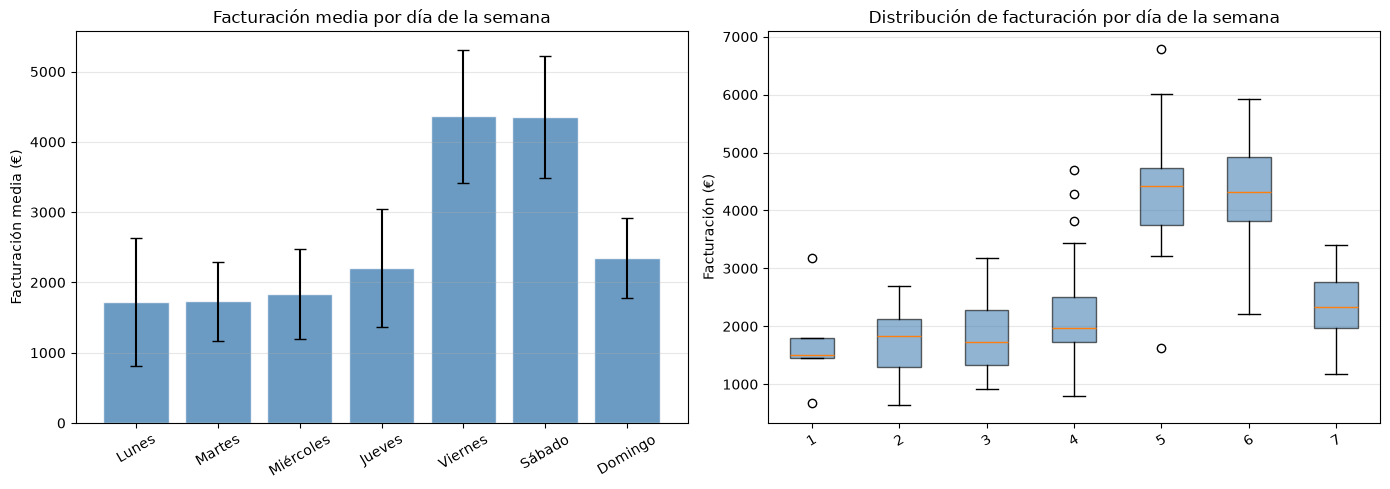

,dia_es,mean,median,std,count
0,Lunes,1720.80,1505.50,913.98,5
1,Martes,1733.10,1832.40,561.06,37
2,Miércoles,1830.59,1726.65,641.81,39
3,Jueves,2208.45,1979.50,842.90,41
4,Viernes,4365.39,4418.17,942.95,40
5,Sábado,4355.42,4316.05,861.89,40
6,Domingo,2349.78,2341.18,573.37,40


In [8]:
# Añadimos variables temporales a la serie diaria para el análisis de patrones.
ingresos_diarios['dia_semana']    = pd.to_datetime(ingresos_diarios['fecha']).dt.day_name()
ingresos_diarios['num_dia']       = pd.to_datetime(ingresos_diarios['fecha']).dt.dayofweek  # 0=lunes
ingresos_diarios['mes']           = pd.to_datetime(ingresos_diarios['fecha']).dt.month

orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
nombres_dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

media_por_dia = (
    ingresos_diarios
    .groupby('dia_semana')['facturacion']
    .agg(['mean','median','std','count'])
    .reindex(orden_dias)
    .reset_index()
)
media_por_dia['dia_es'] = nombres_dias

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras con media y desviación típica
axes[0].bar(media_por_dia['dia_es'], media_por_dia['mean'],
            yerr=media_por_dia['std'], capsize=4,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Facturación media por día de la semana')
axes[0].set_ylabel('Facturación media (€)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# Boxplot para ver distribución completa
data_por_dia = [
    ingresos_diarios.loc[ingresos_diarios['dia_semana'] == d, 'facturacion'].values
    for d in orden_dias
]
axes[1].boxplot(data_por_dia, label=nombres_dias, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Distribución de facturación por día de la semana')
axes[1].set_ylabel('Facturación (€)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'patron_dia_semana.png', dpi=150, bbox_inches='tight')
plt.show()

display(media_por_dia[['dia_es','mean','median','std','count']].round(2))

El patrón por día de la semana es la conclusión más relevante de esta sección y probablemente la feature más importante del modelo. Viernes y sábado facturan de media **4.365€ y 4.355€** respectivamente, más del doble que lunes-miércoles (~1.700-1.800€). El domingo (~2.350€) se sitúa en un nivel intermedio. 

La separación entre días laborables y fin de semana es limpia y consistente (la std dentro de cada día es razonable y los boxplots no se solapan entre el grupo laborable y el grupo fin de semana). **El día de la semana explicará por sí solo una fracción muy significativa de la varianza de la variable objetivo.**

Nota: los lunes tienen solo 5 observaciones (frente a ~40 del resto) porque es el día de cierre habitual. La media de lunes (1.720€) no es representativa — corresponde a los escasos lunes excepcionales en que el restaurante abrió.

#### 2.5. Patrón mensual

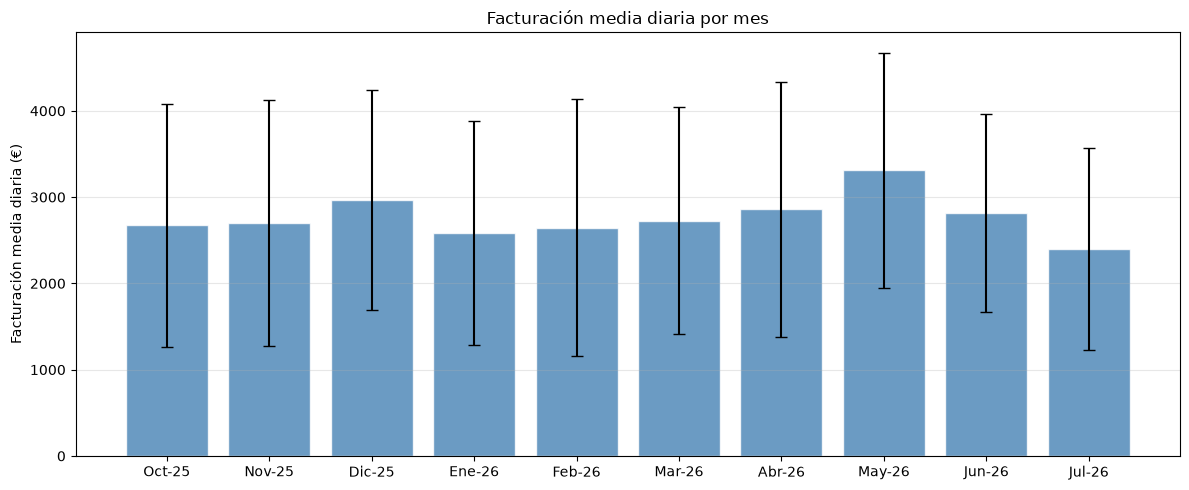

⚠️  Julio-26: solo 8 días disponibles — la media no es comparable al resto de meses.


In [9]:
# Orden cronológico explícito: el mes numérico solo no sirve porque
# el período cruza dos años (oct-25 → jul-26)
orden_meses = {10:0, 11:1, 12:2, 1:3, 2:4, 3:5, 4:6, 5:7, 6:8, 7:9}

media_por_mes = (
    ingresos_diarios
    .groupby('mes')['facturacion']
    .agg(['mean','median','std','count'])
    .reset_index()
)

nombres_meses = {10:'Oct-25', 11:'Nov-25', 12:'Dic-25',
                  1:'Ene-26',  2:'Feb-26',  3:'Mar-26',
                  4:'Abr-26',  5:'May-26',  6:'Jun-26',  7:'Jul-26'}

media_por_mes['mes_label'] = media_por_mes['mes'].map(nombres_meses)
media_por_mes['orden']     = media_por_mes['mes'].map(orden_meses)
media_por_mes = media_por_mes.sort_values('orden')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(media_por_mes['mes_label'], media_por_mes['mean'],
       yerr=media_por_mes['std'], capsize=4,
       color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Facturación media diaria por mes')
ax.set_ylabel('Facturación media diaria (€)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'patron_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

dias_julio = media_por_mes.loc[media_por_mes['mes'] == 7, 'count'].values[0]
print(f"⚠️  Julio-26: solo {dias_julio} días disponibles — la media no es comparable al resto de meses.")

La facturación media diaria es sorprendentemente estable a lo largo de todo el período: todos los meses se sitúan entre 2.600€ y 2.800€, con la excepción de mayo-26 (~3.300€), que podría estar influenciado por eventos puntuales o una concentración de fines de semana favorable ese mes. Las barras de error son amplias y se solapan completamente entre meses, lo que indica que la varianza intramensual (dominada por el efecto día de la semana) supera con creces la varianza intermensual. Julio-26 (~2.400€) tiene datos parciales y no es comparable.

Implicación para el modelo: el mes del año no será una feature discriminante. La señal estacional relevante opera a escala semanal, no mensual. Con un único ciclo anual disponible en los datos, no es posible confirmar ni descartar estacionalidad anual.

#### 2.6. Distribución por ticket y detección de outliers

/var/folders/8p/w0tfqpks0xn1c0tbzdbrcdg00000gr/T/ipykernel_28564/460861348.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_tickets['document_total'], vert=True, patch_artist=True,


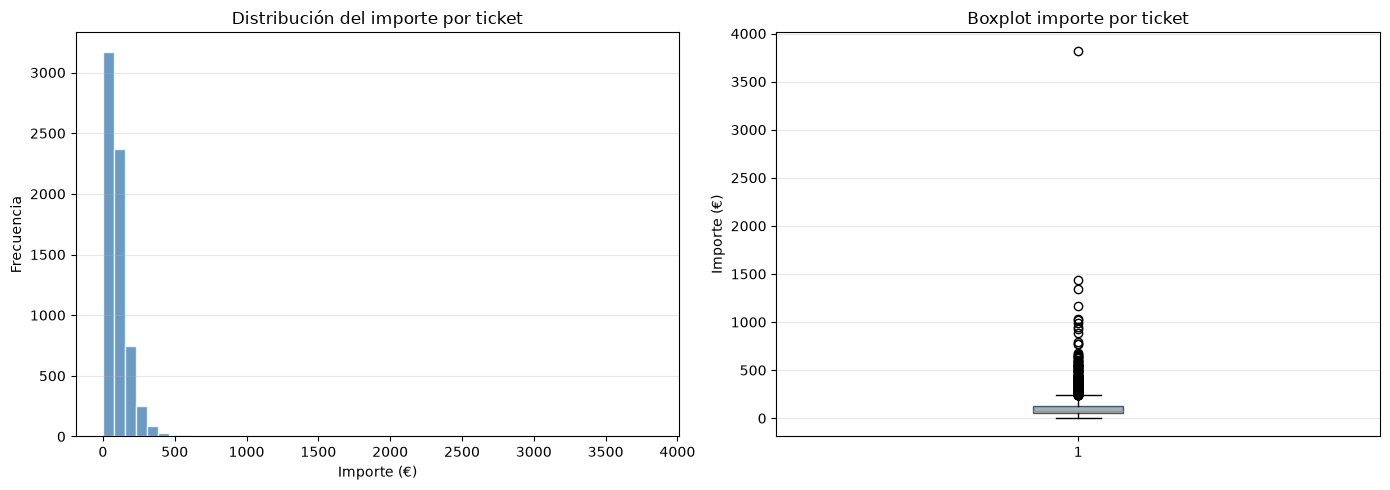

Umbral outlier (Percentil 99): 400.00 €
Tickets por encima del umbral: 67 (1.00%)


,date,document_id,document_total
449,2025-10-18,00001TM00000453,3821.65
1986,2025-12-25,00001TM00002065,1435.00
4512,2026-04-18,00001TM00004630,1344.00
1362,2025-11-28,00001TM00001431,1170.00
1609,2025-12-10,00001TM00001683,1035.00
1991,2025-12-26,00001TM00002070,1025.05
5419,2026-05-22,00001TM00005544,990.00
2123,2026-01-02,00001TM00002204,945.00
1268,2025-11-23,00001TM00001336,927.85
1972,2025-12-24,00001TM00002050,891.00


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_tickets['document_total'], bins=50,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribución del importe por ticket')
axes[0].set_xlabel('Importe (€)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot para identificar outliers visualmente
axes[1].boxplot(df_tickets['document_total'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot importe por ticket')
axes[1].set_ylabel('Importe (€)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distribucion_importe_ticket.png', dpi=150, bbox_inches='tight')
plt.show()

# Umbral percentil 99
lim_sup = df_tickets['document_total'].quantile(0.99)

outliers = df_tickets[df_tickets['document_total'] > lim_sup]
print(f"Umbral outlier (Percentil 99): {lim_sup:.2f} €")
print(f"Tickets por encima del umbral: {len(outliers)} ({len(outliers)/len(df_tickets)*100:.2f}%)")
display(outliers[['date','document_id','document_total']].sort_values('document_total', ascending=False).head(10))

La distribución es fuertemente asimétrica: la mayoría de tickets corresponden a consumiciones individuales o pequeños grupos (moda por debajo de 100€), mientras que la cola derecha recoge mesas grandes y eventos privados. Esta heterogeneidad es operativamente coherente para un restaurante que atiende desde un café de barra hasta cenas de grupo.

Se identifican 67 tickets (1,00%) por encima del umbral de 400€ (Percentil 99), con un máximo de 3.821€. Estos tickets no son errores — son eventos reales de alto valor que  xplican parte de los picos observados en la serie temporal diaria. **No deben eliminarse**, pero sí pueden considerarse como feature (`hay_evento_grande`) si se detecta que coinciden con eventos del calendario.

### 3. Análisis de reservas
- Volumen diario de reservas por turno y estado (confirmada, cancelada, no-show)
- Tasa de cancelación y no-show en el tiempo
- Relación reservas → comensales reales (si está disponible)
- Antelación de la reserva (creación vs. servicio)

In [11]:
df_reservas.info()
print(df_reservas.head(3).to_string())

<class 'pandas.DataFrame'>
RangeIndex: 21289 entries, 0 to 21288
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   source_file           21289 non-null  str           
 1   reservation_datetime  21289 non-null  datetime64[us]
 2   created_datetime      21289 non-null  datetime64[us]
 3   reservation_date      21289 non-null  datetime64[us]
 4   reservation_time      21289 non-null  object        
 5   status                21289 non-null  str           
 6   shift                 21289 non-null  str           
 7   people                21289 non-null  Int64         
 8   origin                21289 non-null  str           
 9   created_date          21289 non-null  datetime64[us]
 10  created_time          21289 non-null  object        
 11  restaurant            21289 non-null  str           
 12  reservation_type      21289 non-null  str           
 13  table                 19845

In [12]:
df_reservas.status_agrupado.value_counts()

status_agrupado
completada    17243
cancelada      2886
liberada        662
no_show         493
pendiente         5
Name: count, dtype: int64

In [13]:
df_reservas.status.value_counts()

status
Sentada                         17080
Cancelado por el cliente         2875
Liberada                          662
No show                           493
Confirmada                        135
Cuenta solicitada                  13
Llegada                            13
Cancelado por el restaurante       11
A revisar                           3
Pendiente                           2
Reconfirmada                        2
Name: count, dtype: int64

df_reservas[df_reservas['status_agrupado'].isin(['pendiente','indefinido'])][
    ['reservation_date','status_agrupado','status']
].sort_values('reservation_date').status.unique()

In [14]:
df_reservas[df_reservas['status_agrupado'] == 'pendiente'][
    ['reservation_date','status_agrupado','status']
].sort_values('reservation_date')

,reservation_date,status_agrupado,status
1767,2023-09-08,pendiente,A revisar
8654,2023-09-08,pendiente,A revisar
9113,2023-10-31,pendiente,Pendiente
10278,2024-03-03,pendiente,Pendiente
12720,2025-01-07,pendiente,A revisar


In [15]:
df_reservas[df_reservas['status_agrupado'] == 'liberada'][
    ['reservation_date','status_agrupado','status']
].sort_values('reservation_date')

,reservation_date,status_agrupado,status
2,2022-11-10,liberada,Liberada
6438,2022-11-10,liberada,Liberada
4,2022-11-13,liberada,Liberada
6442,2022-11-15,liberada,Liberada
6460,2022-11-15,liberada,Liberada
...,...,...,...
20961,2026-06-19,liberada,Liberada
6382,2026-06-21,liberada,Liberada
21049,2026-06-23,liberada,Liberada
21110,2026-06-26,liberada,Liberada


#### 3.1. Exploración inicial

In [16]:
# Valores únicos de las columnas categóricas clave
for col in ['status_agrupado', 'shift', 'origin', 'reservation_type', 'zone', 'restaurant']:
    print(f"\n{col} ({df_reservas[col].nunique()} valores únicos):")
    print(df_reservas[col].value_counts().to_string())


status_agrupado (5 valores únicos):
status_agrupado
completada    17243
cancelada      2886
liberada        662
no_show         493
pendiente         5

shift (2 valores únicos):
shift
Comida    11094
Cena      10195

origin (5 valores únicos):
origin
software     6421
terceros     6346
moduloweb    5255
walk in      3063
appmovil      204

reservation_type (1 valores únicos):
reservation_type
Normal    21289

zone (2 valores únicos):
zone
Sala                14710
Terraza Cubierta     6562

restaurant (1 valores únicos):
restaurant
LA ROCA Pozuelo    21289


#### 3.2. Volumen global por estado

In [17]:
# Distribución global por status_agrupado
# Usamos status_agrupado (columna depurada en Silver) en lugar de status (texto libre)

resumen_status = (
    df_reservas
    .groupby('status_agrupado')
    .agg(
        n_reservas = ('reference_code', 'count'),
        pct        = ('reference_code', lambda x: round(len(x) / len(df_reservas) * 100, 2)),
        comensales = ('people', 'sum'),
    )
    .sort_values('n_reservas', ascending=False)
)

print("Distribución global por estado (histórico completo 2022–2026):")
display(resumen_status)

Distribución global por estado (histórico completo 2022–2026):


,n_reservas,pct,comensales
status_agrupado,,,
completada,17243,80.99,60609
cancelada,2886,13.56,11252
liberada,662,3.11,1909
no_show,493,2.32,1512
pendiente,5,0.02,40


#### 3.3. Volumen por turno y estado

In [18]:
# Cruce turno × estado — relevante para el modelo porque
# el comportamiento de cancelación puede diferir entre comida y cena

pivot_turno_status = (
    df_reservas
    .groupby(['shift', 'status_agrupado'])
    .size()
    .unstack(fill_value=0)
)

# Añadimos porcentajes sobre el total de cada turno
pivot_turno_pct = pivot_turno_status.div(pivot_turno_status.sum(axis=1), axis=0).round(3) * 100

print("Volumen absoluto por turno y estado:")
display(pivot_turno_status)
print("\nPorcentaje por turno y estado:")
display(pivot_turno_pct)

Volumen absoluto por turno y estado:


status_agrupado,cancelada,completada,liberada,no_show,pendiente
shift,,,,,
Cena,1496,8096,359,242,2
Comida,1390,9147,303,251,3



Porcentaje por turno y estado:


status_agrupado,cancelada,completada,liberada,no_show,pendiente
shift,,,,,
Cena,14.7,79.4,3.5,2.4,0.0
Comida,12.5,82.4,2.7,2.3,0.0


#### 3.4. Distribución por estado y turno

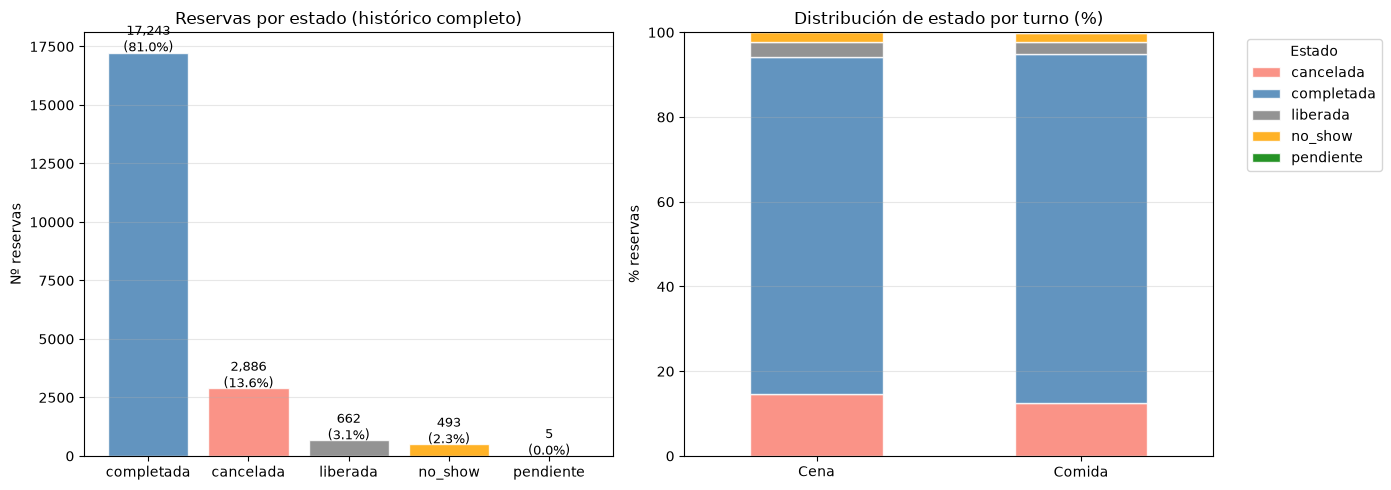

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: volumen absoluto por estado
colores_status = {'completada': 'steelblue', 'cancelada': 'salmon', 'no_show': 'orange', 'pendiente': 'green', 'liberada': 'grey'}
status_counts = df_reservas['status_agrupado'].value_counts()

axes[0].bar(status_counts.index,
            status_counts.values,
            color=[colores_status.get(s, 'grey') for s in status_counts.index],
            edgecolor='white', alpha=0.85)
axes[0].set_title('Reservas por estado (histórico completo)')
axes[0].set_ylabel('Nº reservas')
axes[0].grid(axis='y', alpha=0.3)
for i, (idx, val) in enumerate(status_counts.items()):
    axes[0].text(i, val + 50, f'{val:,}\n({val/len(df_reservas)*100:.1f}%)',
                 ha='center', fontsize=9)

# Panel derecho: stacked bar por turno
pivot_turno_pct.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[colores_status.get(c, 'grey') for c in pivot_turno_pct.columns],
    edgecolor='white', alpha=0.85
)
axes[1].set_title('Distribución de estado por turno (%)')
axes[1].set_ylabel('% reservas')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'reservas_estado_turno.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.5. Tasa de cancelación

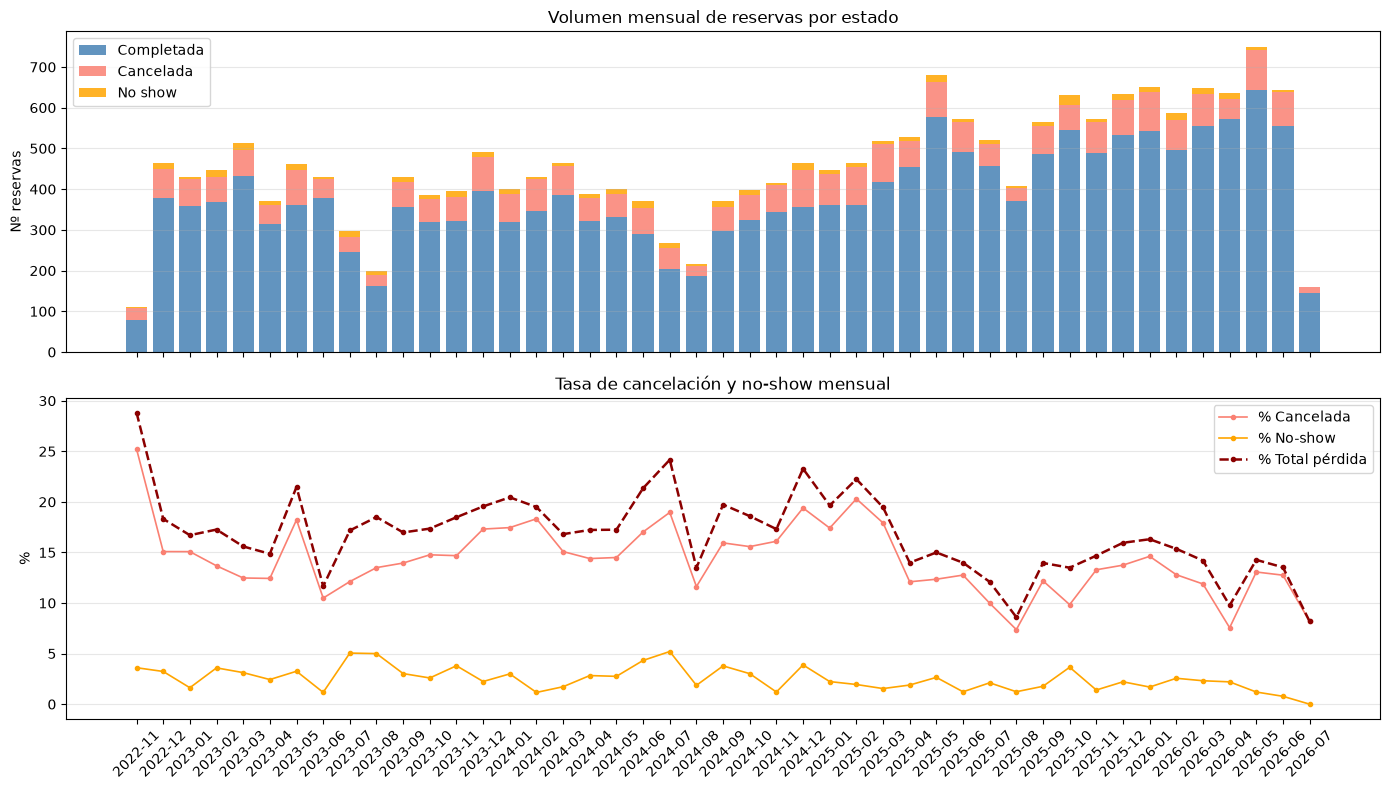

In [20]:
# Agregamos por mes para ver evolución temporal
# Filtramos al período con datos de ventas (oct-25 en adelante) para
# poder cruzar con facturación más adelante, pero mostramos desde 2022
# para ver si hay cambio de tendencia

df_reservas['anyo_mes'] = df_reservas['reservation_date'].dt.to_period('M')

evolucion_mensual = (
    df_reservas
    .groupby(['anyo_mes', 'status_agrupado'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

evolucion_mensual['total']       = evolucion_mensual[['completada','cancelada','no_show']].sum(axis=1)
evolucion_mensual['pct_cancelada'] = evolucion_mensual['cancelada'] / evolucion_mensual['total'] * 100
evolucion_mensual['pct_no_show']   = evolucion_mensual['no_show']   / evolucion_mensual['total'] * 100
evolucion_mensual['pct_perdida']   = evolucion_mensual['pct_cancelada'] + evolucion_mensual['pct_no_show']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

x = evolucion_mensual['anyo_mes'].astype(str)

# Panel superior: volumen absoluto apilado
axes[0].bar(x, evolucion_mensual['completada'], label='Completada',
            color='steelblue', alpha=0.85)
axes[0].bar(x, evolucion_mensual['cancelada'],  label='Cancelada',
            bottom=evolucion_mensual['completada'], color='salmon', alpha=0.85)
axes[0].bar(x, evolucion_mensual['no_show'],    label='No show',
            bottom=evolucion_mensual['completada'] + evolucion_mensual['cancelada'],
            color='orange', alpha=0.85)
axes[0].set_title('Volumen mensual de reservas por estado')
axes[0].set_ylabel('Nº reservas')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Panel inferior: tasa de pérdida (cancelada + no-show)
axes[1].plot(x, evolucion_mensual['pct_cancelada'], color='salmon',
             marker='o', markersize=3, linewidth=1.2, label='% Cancelada')
axes[1].plot(x, evolucion_mensual['pct_no_show'], color='orange',
             marker='o', markersize=3, linewidth=1.2, label='% No-show')
axes[1].plot(x, evolucion_mensual['pct_perdida'], color='darkred',
             marker='o', markersize=3, linewidth=1.8, linestyle='--', label='% Total pérdida')
axes[1].set_title('Tasa de cancelación y no-show mensual')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'reservas_evolucion_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

**Nota metodológica — `total` y tasas de pérdida:** se calculan únicamente
sobre desenlaces resueltos con interpretación binaria clara (`completada`,
`cancelada`, `no_show`). Se excluyen `pendiente` (desenlace aún no
conocido) y `liberada` (desenlace ambiguo, ver justificación en
`02_depuracion_silver`). Incluir cualquiera de las dos distorsionaría
`pct_cancelada`/`pct_no_show` sin aportar una interpretación de negocio
consistente.

#### 3.6. Antelación de la reserva

Registros con antelación válida: 18,193 (85.5%)

Estadísticas de antelación (días):


,count,mean,std,min,25%,50%,75%,max
antelacion_dias,18193.0,1.95,5.07,0.0,0.09,0.54,1.92,209.2



Walk-ins (antelación < 1h): 2,342
es_walk_in flag en Silver:  3,063

Antelación media por estado:


,mean,median,count
status_agrupado,,,
cancelada,3.33,1.08,2842
completada,1.68,0.38,14376
liberada,1.18,0.23,479
no_show,2.87,0.59,491
pendiente,2.99,0.87,5


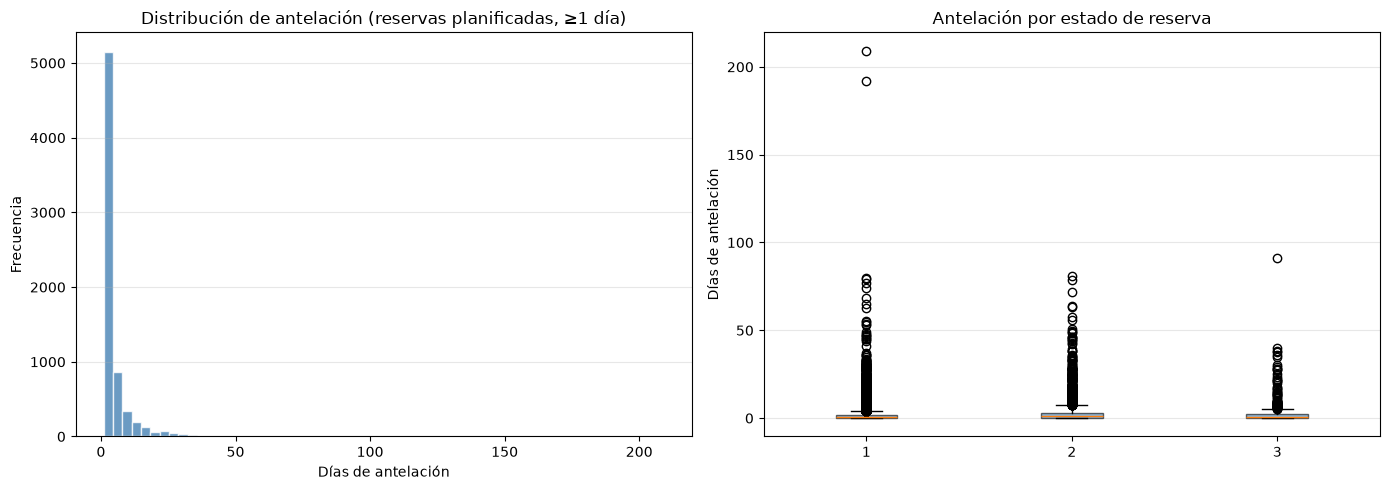

In [21]:
# Antelación = reservation_datetime - created_datetime
# Mide cuántos días antes se hace la reserva respecto al servicio

df_reservas['antelacion_dias'] = df_reservas['antelacion_horas'] / 24

# Descartamos antelaciones negativas (errores de registro) y > 365 días
antelacion_valida = df_reservas[
    (df_reservas['antelacion_dias'] >= 0) &
    (df_reservas['antelacion_dias'] <= 365)
].copy()

print(f"Registros con antelación válida: {len(antelacion_valida):,} "
      f"({len(antelacion_valida)/len(df_reservas)*100:.1f}%)")
print()
print("Estadísticas de antelación (días):")
display(antelacion_valida['antelacion_dias'].describe().round(2).to_frame().T)

# Walk-ins: antelación < 1 hora (reserva y servicio el mismo momento)
walk_ins_real = (antelacion_valida['antelacion_dias'] < 1/24).sum()
print(f"\nWalk-ins (antelación < 1h): {walk_ins_real:,}")
print(f"es_walk_in flag en Silver:  {df_reservas['es_walk_in'].sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de antelación (sin walk-ins para no distorsionar)
reservas_planificadas = antelacion_valida[antelacion_valida['antelacion_dias'] >= 1]
axes[0].hist(reservas_planificadas['antelacion_dias'], bins=60,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribución de antelación (reservas planificadas, ≥1 día)')
axes[0].set_xlabel('Días de antelación')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

# Antelación media por estado — ¿cancelan antes o después?
antelacion_por_status = (
    antelacion_valida
    .groupby('status_agrupado')['antelacion_dias']
    .agg(['mean','median','count'])
    .round(2)
)
print("\nAntelación media por estado:")
display(antelacion_por_status)

# Boxplot antelación por estado
data_box = [
    antelacion_valida.loc[antelacion_valida['status_agrupado'] == s, 'antelacion_dias'].values
    for s in ['completada', 'cancelada', 'no_show']
]
axes[1].boxplot(data_box, label=['Completada', 'Cancelada', 'No-show'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Antelación por estado de reserva')
axes[1].set_ylabel('Días de antelación')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'reservas_antelacion.png', dpi=150, bbox_inches='tight')
plt.show()

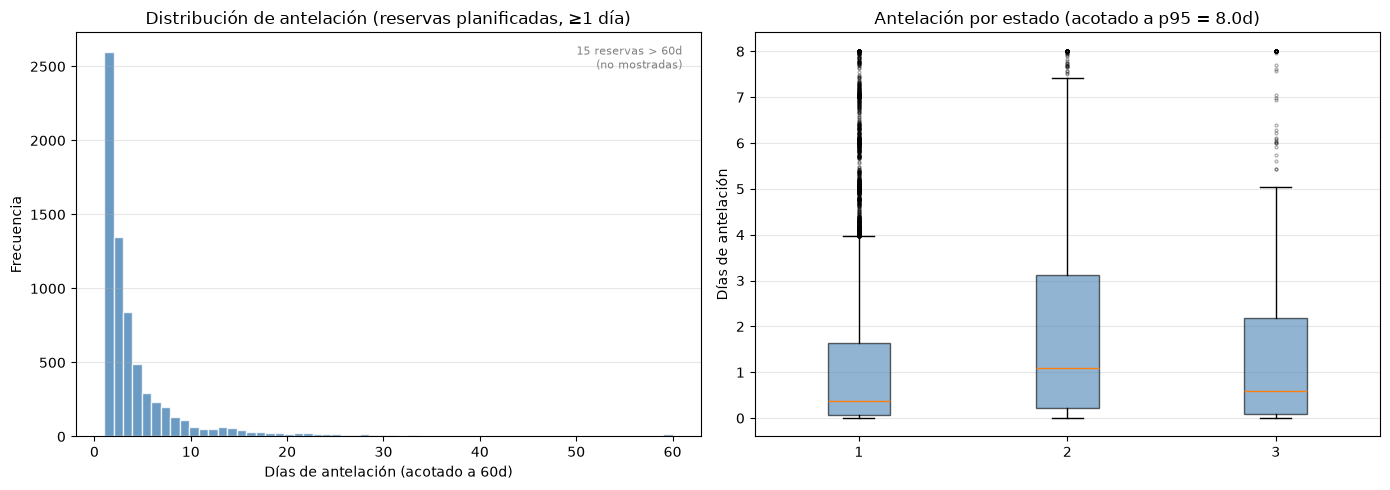

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: histograma acotado a 60 días (cubre >95% de casos)
reservas_planificadas = antelacion_valida[antelacion_valida['antelacion_dias'] >= 1]
axes[0].hist(reservas_planificadas['antelacion_dias'].clip(upper=60), bins=60,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribución de antelación (reservas planificadas, ≥1 día)')
axes[0].set_xlabel('Días de antelación (acotado a 60d)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)
n_fuera = (reservas_planificadas['antelacion_dias'] > 60).sum()
axes[0].text(0.97, 0.97, f'{n_fuera} reservas > 60d\n(no mostradas)',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=8, color='grey')

# Panel derecho: boxplot acotado a percentil 95 para ver cajas
p95 = antelacion_valida['antelacion_dias'].quantile(0.95)
data_box = [
    antelacion_valida.loc[
        antelacion_valida['status_agrupado'] == s, 'antelacion_dias'
    ].clip(upper=p95).values
    for s in ['completada', 'cancelada', 'no_show']
]
axes[1].boxplot(data_box, label=['Completada', 'Cancelada', 'No-show'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_title(f'Antelación por estado (acotado a p95 = {p95:.1f}d)')
axes[1].set_ylabel('Días de antelación')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'reservas_antelacion.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.7. Walk-ins

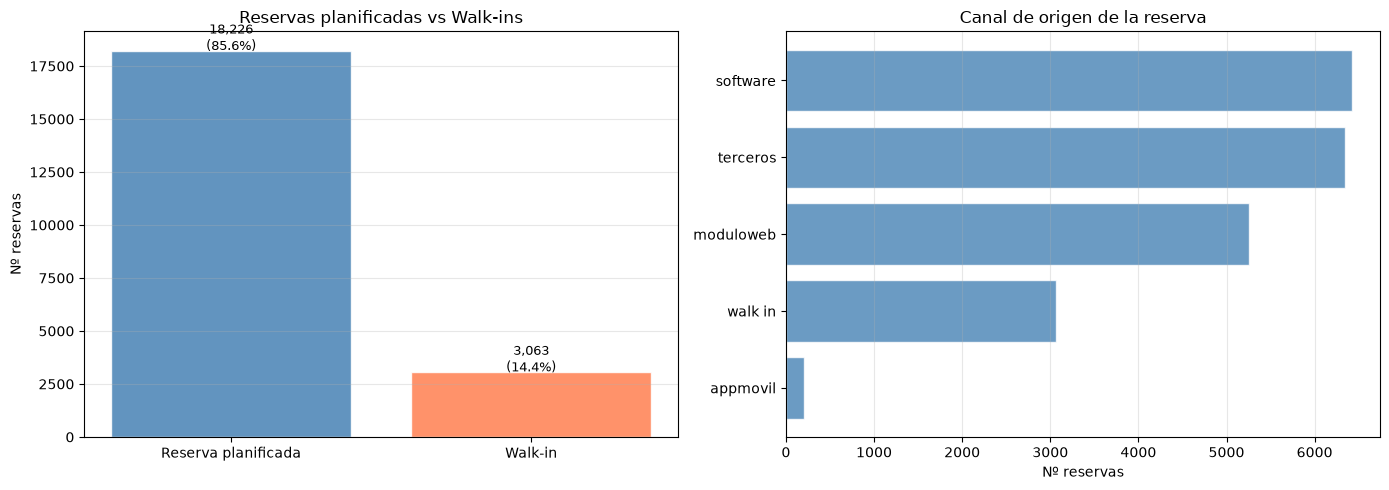

In [23]:
# Walk-ins: reservas sin planificación previa
# es_walk_in ya viene depurado desde Silver

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Walk-in vs reserva planificada
walkin_counts = df_reservas['es_walk_in'].value_counts()
axes[0].bar(['Reserva planificada', 'Walk-in'],
            [walkin_counts.get(False, 0), walkin_counts.get(True, 0)],
            color=['steelblue', 'coral'], alpha=0.85, edgecolor='white')
axes[0].set_title('Reservas planificadas vs Walk-ins')
axes[0].set_ylabel('Nº reservas')
axes[0].grid(axis='y', alpha=0.3)
for i, val in enumerate([walkin_counts.get(False, 0), walkin_counts.get(True, 0)]):
    axes[0].text(i, val + 30, f'{val:,}\n({val/len(df_reservas)*100:.1f}%)',
                 ha='center', fontsize=9)

# Canal de origen
origin_counts = df_reservas['origin'].value_counts().head(8)
axes[1].barh(origin_counts.index[::-1], origin_counts.values[::-1],
             color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('Canal de origen de la reserva')
axes[1].set_xlabel('Nº reservas')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'reservas_walkin_origen.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.8. Distribución y grupos de comensales

Estadísticas de comensales por reserva:


,count,mean,std,min,25%,50%,75%,max
people,21289.0,3.54,2.21,1.0,2.0,3.0,4.0,50.0


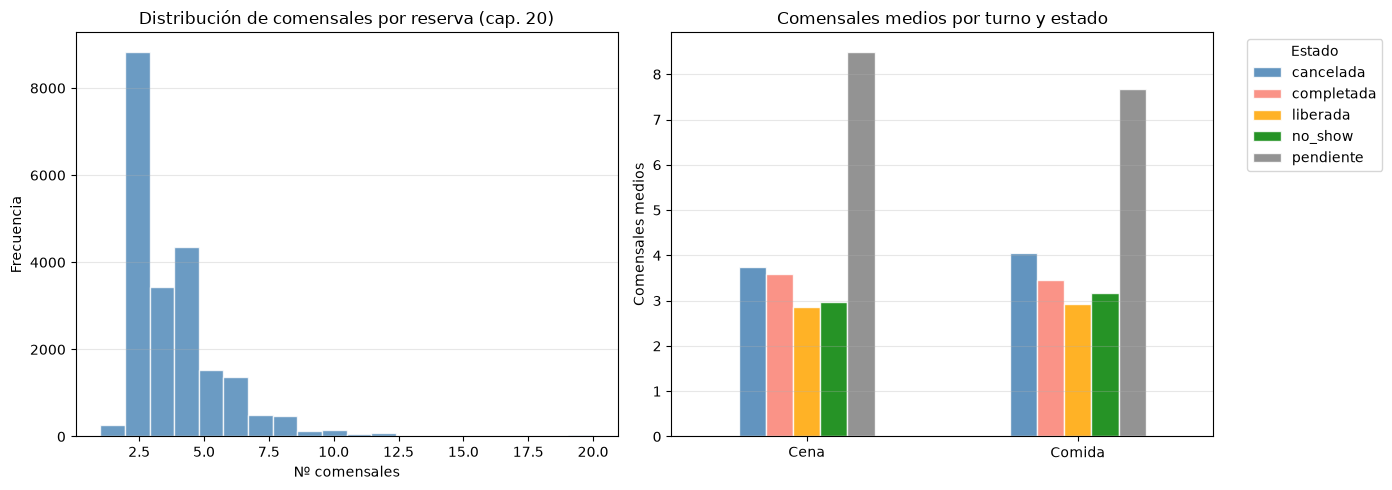


Reservas marcadas como grupo grande: 27 (0.1%)

Estadísticas de comensales en grupos grandes:


,count,mean,std,min,25%,50%,75%,max
people,27.0,28.93,8.55,21.0,22.5,25.0,33.5,50.0


In [24]:
# people = nº de comensales por reserva
# es_grupo_grande ya viene depurado desde Silver

print("Estadísticas de comensales por reserva:")
display(df_reservas['people'].describe().round(2).to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de comensales
axes[0].hist(df_reservas['people'].clip(upper=20), bins=20,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribución de comensales por reserva (cap. 20)')
axes[0].set_xlabel('Nº comensales')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

# Comensales medios por turno y estado
comensales_turno = (
    df_reservas
    .groupby(['shift', 'status_agrupado'])['people']
    .mean()
    .unstack()
    .round(2)
)
comensales_turno.plot(kind='bar', ax=axes[1],
                      color=['steelblue', 'salmon', 'orange', 'green', 'gray'],
                      alpha=0.85, edgecolor='white')
axes[1].set_title('Comensales medios por turno y estado')
axes[1].set_ylabel('Comensales medios')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'reservas_comensales.png', dpi=150, bbox_inches='tight')
plt.show()

# Grupos grandes
print(f"\nReservas marcadas como grupo grande: {df_reservas['es_grupo_grande'].sum():,} "
      f"({df_reservas['es_grupo_grande'].mean()*100:.1f}%)")
print("\nEstadísticas de comensales en grupos grandes:")
display(df_reservas.loc[df_reservas['es_grupo_grande'], 'people'].describe().round(2).to_frame().T)

`pendiente` (n=5) no debe interpretarse cuantitativamente por tamaño de muestra

#### 3.9. Reservas diarias en periodo de facturación

Reservas en período operativo (desde oct-25): 6,133


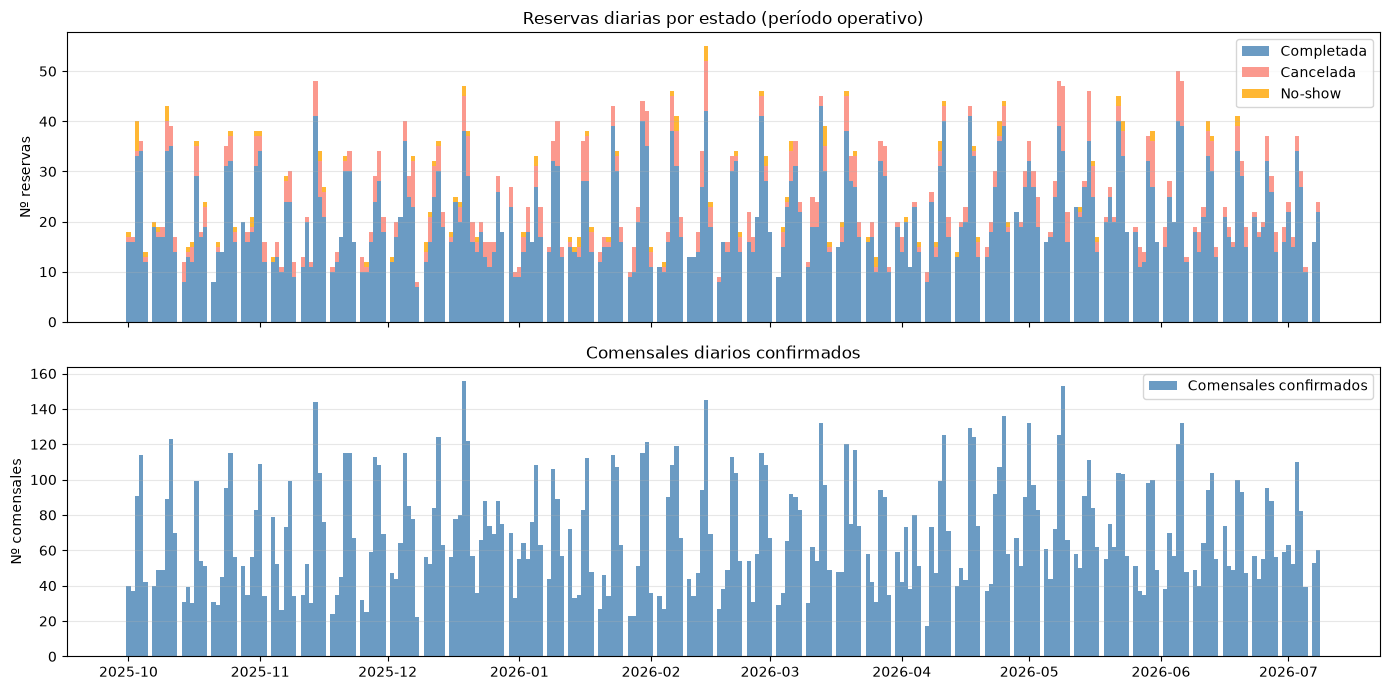

In [25]:
# Para cruzar con facturación solo usamos el período con datos de ventas

FECHA_INICIO_OPERATIVO = pd.Timestamp('2025-10-01')

df_reservas_op = df_reservas[
    df_reservas['reservation_date'] >= FECHA_INICIO_OPERATIVO
].copy()

print(f"Reservas en período operativo (desde oct-25): {len(df_reservas_op):,}")

reservas_diarias = (
    df_reservas_op
    .groupby(['reservation_date', 'status_agrupado'])
    .agg(
        n_reservas = ('reference_code', 'count'),
        comensales = ('people', 'sum'),
    )
    .unstack(fill_value=0)
    .reset_index()
)

# Aplanamos columnas MultiIndex
reservas_diarias.columns = [
    'fecha' if col[1] == '' else f'{col[0]}_{col[1]}'
    for col in reservas_diarias.columns
]

reservas_diarias['fecha'] = pd.to_datetime(reservas_diarias['fecha'])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].bar(reservas_diarias['fecha'],
            reservas_diarias.get('n_reservas_completada', 0),
            label='Completada', color='steelblue', alpha=0.8, width=1)
axes[0].bar(reservas_diarias['fecha'],
            reservas_diarias.get('n_reservas_cancelada', 0),
            bottom=reservas_diarias.get('n_reservas_completada', 0),
            label='Cancelada', color='salmon', alpha=0.8, width=1)
axes[0].bar(reservas_diarias['fecha'],
            reservas_diarias.get('n_reservas_no_show', 0),
            bottom=(reservas_diarias.get('n_reservas_completada', 0) +
                    reservas_diarias.get('n_reservas_cancelada', 0)),
            label='No-show', color='orange', alpha=0.8, width=1)
axes[0].set_title('Reservas diarias por estado (período operativo)')
axes[0].set_ylabel('Nº reservas')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(reservas_diarias['fecha'],
            reservas_diarias.get('comensales_completada', 0),
            color='steelblue', alpha=0.8, width=1, label='Comensales confirmados')
axes[1].set_title('Comensales diarios confirmados')
axes[1].set_ylabel('Nº comensales')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'reservas_diarias_operativo.png', dpi=150, bbox_inches='tight')
plt.show()

### 4. Análisis de producto (ventas por artículo y departamento)
- Artículos y departamentos más vendidos (volumen e importe)
- Concentración: ¿cuántos artículos explican el 80% de la facturación? (Pareto)
- Estacionalidad por categoría/departamento

> ⚠️ Ojo: `total_articles` es un agregado global sin granularidad diaria. No mezclar con `ventas` sin aclarar qué se está mirando.

In [26]:
df_ventas.info()
print(df_ventas.head(3).to_string())
print("---")
df_artic.info()
print(df_artic.head(3).to_string())

<class 'pandas.DataFrame'>
RangeIndex: 5532 entries, 0 to 5531
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   source_file          5532 non-null   str           
 1   report_start         5532 non-null   datetime64[us]
 2   report_end           5532 non-null   datetime64[us]
 3   report_generated_on  5532 non-null   datetime64[us]
 4   terminal_start       5532 non-null   str           
 5   terminal_end         5532 non-null   str           
 6   turn                 5532 non-null   str           
 7   department_code      5532 non-null   Int64         
 8   department_name      5532 non-null   str           
 9   article_code         5532 non-null   Int64         
 10  article_name         5532 non-null   str           
 11  units                5532 non-null   float64       
 12  amount               5532 non-null   float64       
 13  es_invitacion        5532 non-null   bool   

In [27]:
# Excluimos invitaciones: no generan ingreso real y distorsionarían
# tanto el ranking de artículos como el análisis de Pareto
df_ventas_op = df_ventas[~df_ventas['es_invitacion']].copy()

print(f"Registros totales en ventas     : {len(df_ventas):,}")
print(f"Registros excluidos (invitación): {df_ventas['es_invitacion'].sum():,} "
      f"({df_ventas['es_invitacion'].mean()*100:.1f}%)")
print(f"Registros para análisis         : {len(df_ventas_op):,}")
print()

# Verificamos los turnos disponibles
print("Turnos:", df_ventas_op['turn'].unique())

# Granularidad temporal disponible: semanal (report_start → report_end)
# No hay granularidad diaria en df_ventas — el análisis temporal
# se hará a nivel de semana usando report_start como ancla
print(f"\nPeríodo: {df_ventas_op['report_start'].min().date()} "
      f"→ {df_ventas_op['report_end'].max().date()}")
print(f"Semanas distintas: {df_ventas_op['report_start'].nunique()}")
print(f"Artículos distintos: {df_ventas_op['article_code'].nunique()}")
print(f"Departamentos distintos: {df_ventas_op['department_code'].nunique()}")

Registros totales en ventas     : 5,532
Registros excluidos (invitación): 26 (0.5%)
Registros para análisis         : 5,506

Turnos: <ArrowStringArray>
['T']
Length: 1, dtype: str

Período: 2025-10-01 → 2026-07-09
Semanas distintas: 41
Artículos distintos: 251
Departamentos distintos: 18


#### 4.1. Ranking de "áreas"

In [28]:
ranking_depto = (
    df_ventas_op
    .groupby(['department_code', 'department_name'])
    .agg(
        units  = ('units',  'sum'),
        amount = ('amount', 'sum'),
    )
    .reset_index()
    .sort_values('amount', ascending=False)
)

ranking_depto['pct_amount'] = ranking_depto['amount'] / ranking_depto['amount'].sum() * 100
ranking_depto['pct_acum']   = ranking_depto['pct_amount'].cumsum()

print("Ranking de departamentos por facturación:")
display(ranking_depto[['department_name','units','amount','pct_amount','pct_acum']].round(2))

Ranking de departamentos por facturación:


,department_name,units,amount,pct_amount,pct_acum
2,CARTA,9330.0,163075.58,26.51,26.51
10,SUGERENCIAS,6544.0,62852.70,10.22,36.73
14,CLASICOS,9619.0,54873.07,8.92,45.65
11,OTROS,16241.0,51323.32,8.34,53.99
0,TAPAS CALIENTES,7847.0,48869.91,7.94,61.94
4,CERVEZAS,11337.0,43816.26,7.12,69.06
9,POSTRES,9357.0,39787.07,6.47,75.53
16,MENU DEL DIA,1892.0,34940.91,5.68,81.21
7,TINTOS,3520.0,30088.16,4.89,86.10
3,REFRESCOS,9396.0,26761.81,4.35,90.45


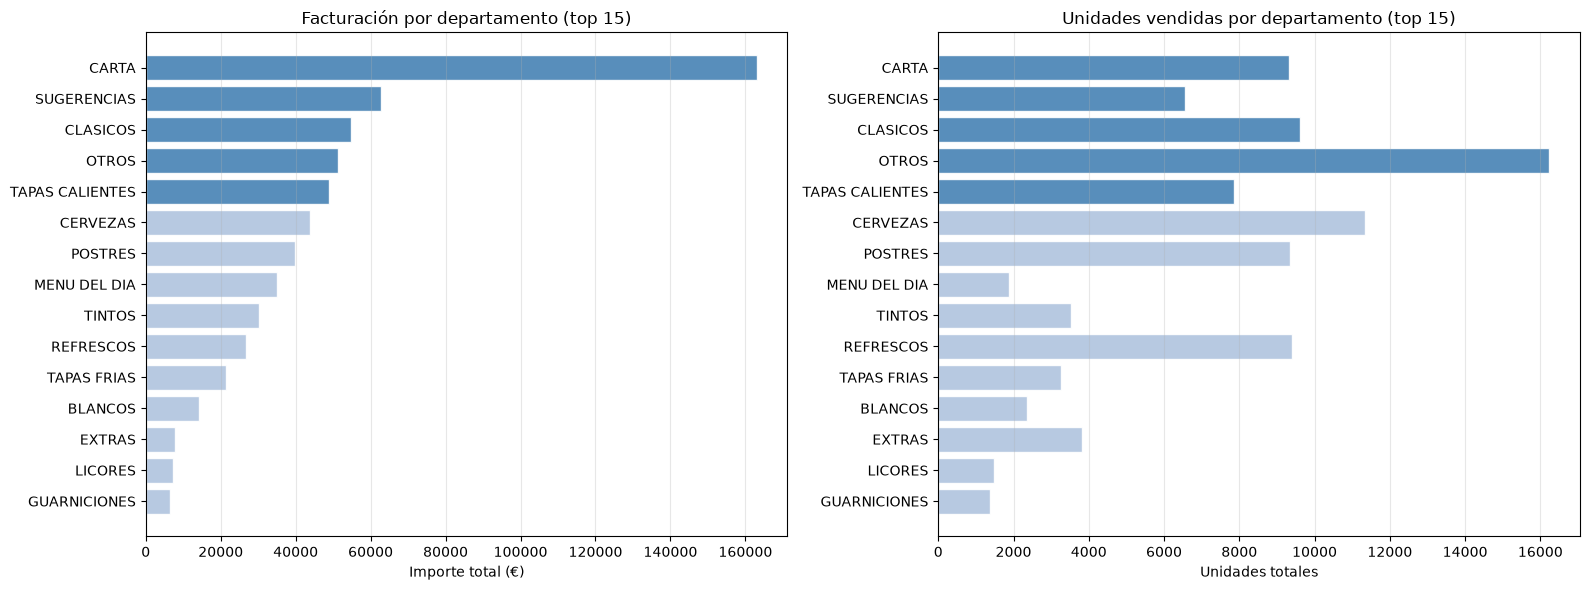

In [29]:
# Top departamentos — mostramos todos si son manejables (<= 23)
top_n = min(15, len(ranking_depto))
top_depto = ranking_depto.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: facturación por departamento
colores = ['steelblue' if i < 5 else 'lightsteelblue' for i in range(top_n)]
axes[0].barh(top_depto['department_name'][::-1],
             top_depto['amount'][::-1],
             color=colores[::-1], edgecolor='white', alpha=0.9)
axes[0].set_title(f'Facturación por departamento (top {top_n})')
axes[0].set_xlabel('Importe total (€)')
axes[0].grid(axis='x', alpha=0.3)

# Panel derecho: unidades vendidas
axes[1].barh(top_depto['department_name'][::-1],
             top_depto['units'][::-1],
             color=colores[::-1], edgecolor='white', alpha=0.9)
axes[1].set_title(f'Unidades vendidas por departamento (top {top_n})')
axes[1].set_xlabel('Unidades totales')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'producto_departamentos.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.2. Ranking de artículos

In [30]:
ranking_artic = (
    df_ventas_op
    .groupby(['article_code', 'article_name', 'department_name'])
    .agg(
        units  = ('units',  'sum'),
        amount = ('amount', 'sum'),
    )
    .reset_index()
    .sort_values('amount', ascending=False)
    .reset_index(drop=True)
)

ranking_artic['pct_amount'] = ranking_artic['amount'] / ranking_artic['amount'].sum() * 100
ranking_artic['pct_acum']   = ranking_artic['pct_amount'].cumsum()

# ¿Cuántos artículos explican el 80% de la facturación?
n_80 = (ranking_artic['pct_acum'] <= 80).sum() + 1
n_total = len(ranking_artic)
print(f"Total artículos con ventas: {n_total}")
print(f"Artículos que explican el 80% de la facturación: {n_80} ({n_80/n_total*100:.1f}%)")
print(f"Artículos que explican el 50% de la facturación: "
      f"{(ranking_artic['pct_acum'] <= 50).sum() + 1}")
print()
print("Top 15 artículos por facturación:")
display(ranking_artic[['article_name','department_name','units','amount','pct_amount','pct_acum']].head(15).round(2))

Total artículos con ventas: 265
Artículos que explican el 80% de la facturación: 57 (21.5%)
Artículos que explican el 50% de la facturación: 22

Top 15 artículos por facturación:


,article_name,department_name,units,amount,pct_amount,pct_acum
0,MENU DEL DIA,MENU DEL DIA,1892.0,34940.91,5.68,5.68
1,OTROS DESCRIPCIÓN,OTROS,827.0,26110.05,4.24,9.93
2,RACIÓN DE PAN,OTROS,15332.0,25064.18,4.07,14.00
3,COPA DE VICTORIA,CERVEZAS,5304.0,23132.52,3.76,17.76
4,PLUMA DE BELLOTA A LA BRASA,CARTA,730.0,18541.08,3.01,20.77
5,CHULETON DE VACA VIEJA,CARTA,551.0,17630.91,2.87,23.64
6,SAM DE GAMBAS,CLASICOS,3128.0,15478.50,2.52,26.16
7,TARTAR DE ATUN,CARTA,868.0,15047.95,2.45,28.60
8,RAVIOLI DE RABO DE TERNERA,CLASICOS,2455.0,14722.80,2.39,31.00
9,ALCACHOFA A LA BRASA,CARTA,834.0,12868.09,2.09,33.09


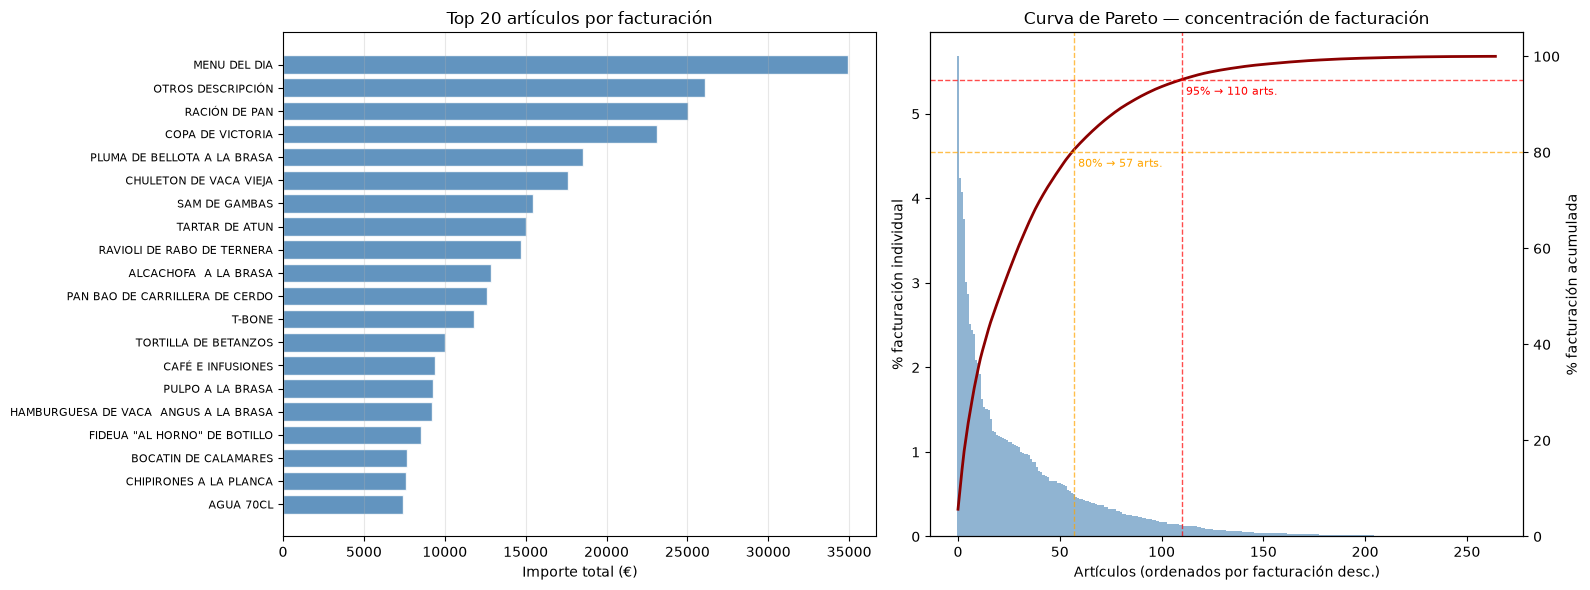

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: top 20 artículos por facturación
top20 = ranking_artic.head(20)
axes[0].barh(top20['article_name'][::-1],
             top20['amount'][::-1],
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Top 20 artículos por facturación')
axes[0].set_xlabel('Importe total (€)')
axes[0].grid(axis='x', alpha=0.3)
axes[0].tick_params(axis='y', labelsize=8)

# Panel derecho: curva de Pareto
ax2 = axes[1]
ax2b = ax2.twinx()

ax2.bar(range(n_total), ranking_artic['pct_amount'],
        color='steelblue', alpha=0.6, width=1)
ax2b.plot(range(n_total), ranking_artic['pct_acum'],
          color='darkred', linewidth=2)

# Líneas de referencia
for umbral, color in [(80, 'orange'), (95, 'red')]:
    n_umbral = (ranking_artic['pct_acum'] <= umbral).sum() + 1
    ax2b.axhline(umbral, color=color, linestyle='--', linewidth=1, alpha=0.7)
    ax2b.axvline(n_umbral, color=color, linestyle='--', linewidth=1, alpha=0.7)
    ax2b.text(n_umbral + 2, umbral - 3, f'{umbral}% → {n_umbral} arts.',
              color=color, fontsize=8)

ax2.set_title('Curva de Pareto — concentración de facturación')
ax2.set_xlabel('Artículos (ordenados por facturación desc.)')
ax2.set_ylabel('% facturación individual')
ax2b.set_ylabel('% facturación acumulada')
ax2b.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'producto_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.3. Estacionalidad semanal por áreas

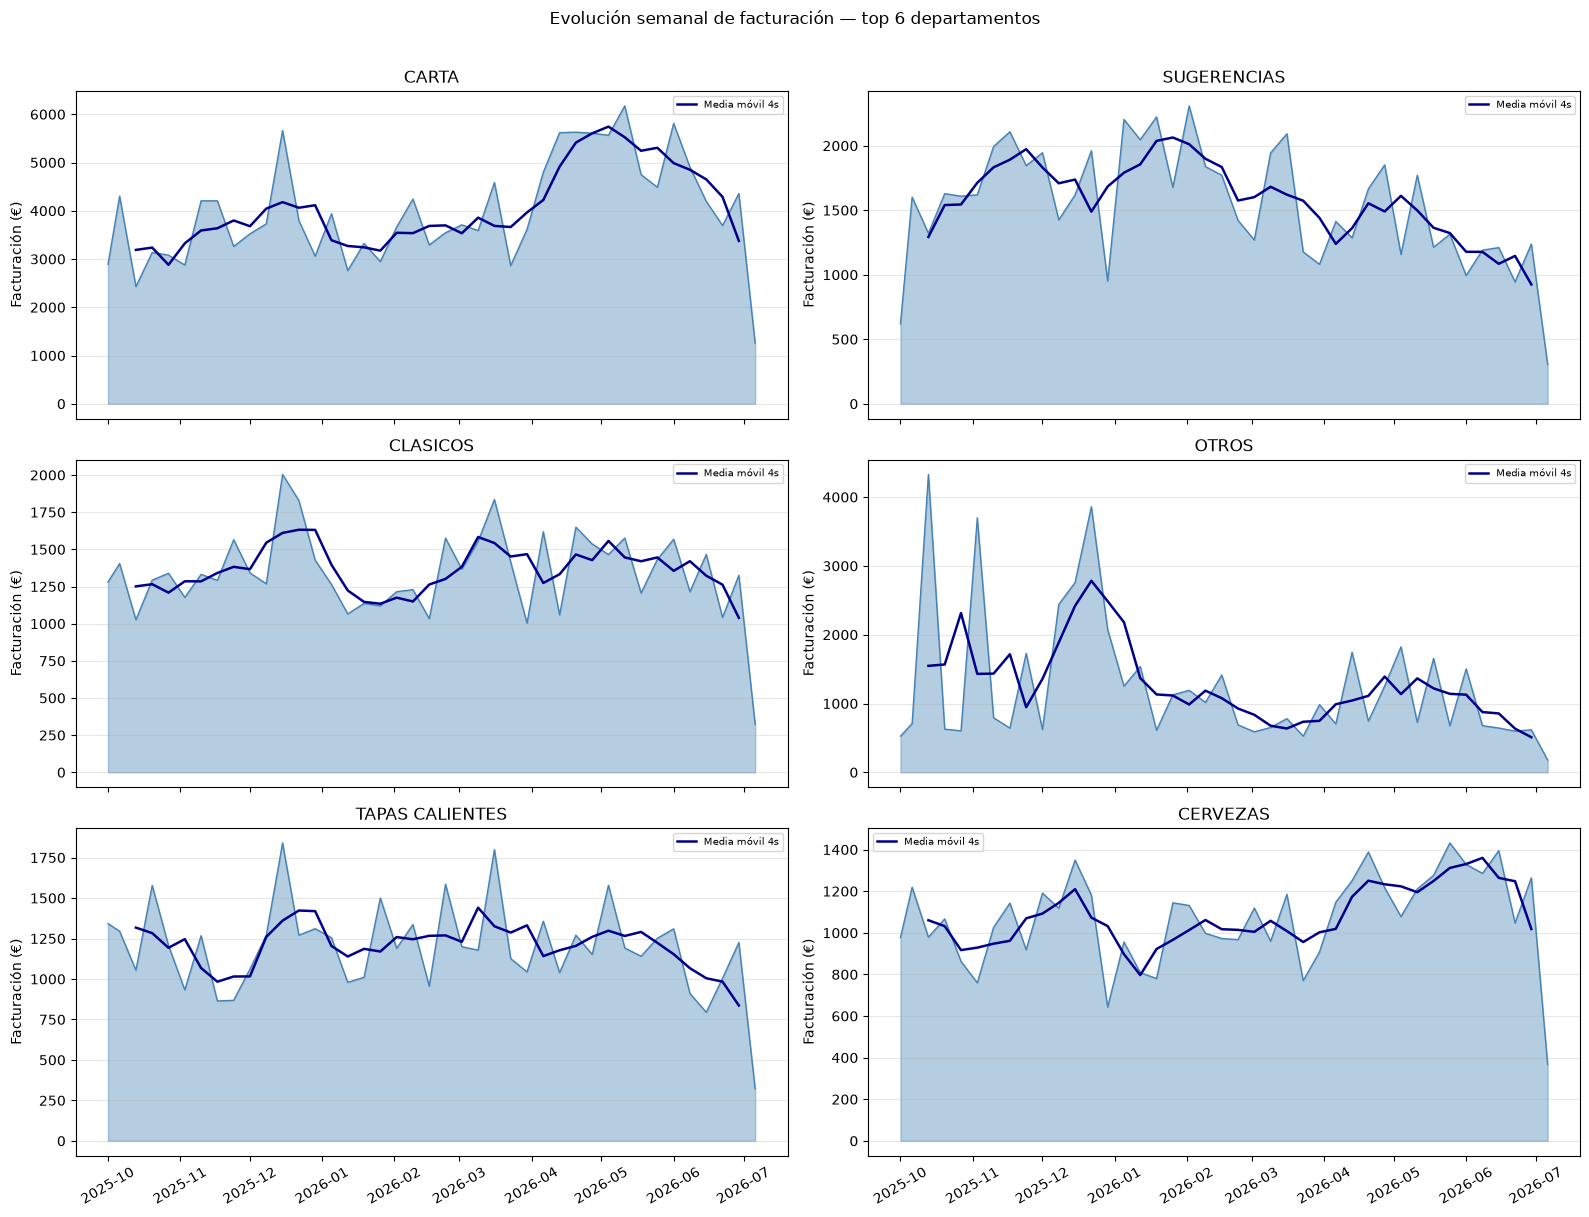

In [32]:
# Granularidad máxima disponible: semanal (report_start)
# Seleccionamos los top 6 departamentos por facturación total para no saturar el gráfico

top6_deptos = ranking_depto.head(6)['department_name'].tolist()

evolucion_depto = (
    df_ventas_op[df_ventas_op['department_name'].isin(top6_deptos)]
    .groupby(['report_start', 'department_name'])['amount']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
    .sort_values('report_start')
)

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for i, depto in enumerate(top6_deptos):
    if depto in evolucion_depto.columns:
        axes[i].fill_between(evolucion_depto['report_start'],
                             evolucion_depto[depto],
                             alpha=0.4, color='steelblue')
        axes[i].plot(evolucion_depto['report_start'],
                     evolucion_depto[depto],
                     color='steelblue', linewidth=1)
        # Media móvil 4 semanas
        ma4 = evolucion_depto[depto].rolling(4, center=True).mean()
        axes[i].plot(evolucion_depto['report_start'], ma4,
                     color='darkblue', linewidth=1.8, label='Media móvil 4s')
        axes[i].set_title(depto)
        axes[i].set_ylabel('Facturación (€)')
        axes[i].grid(axis='y', alpha=0.3)
        axes[i].legend(fontsize=7)
        axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Evolución semanal de facturación — top 6 departamentos', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'producto_estacionalidad_departamento.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.4. Mix por turnos

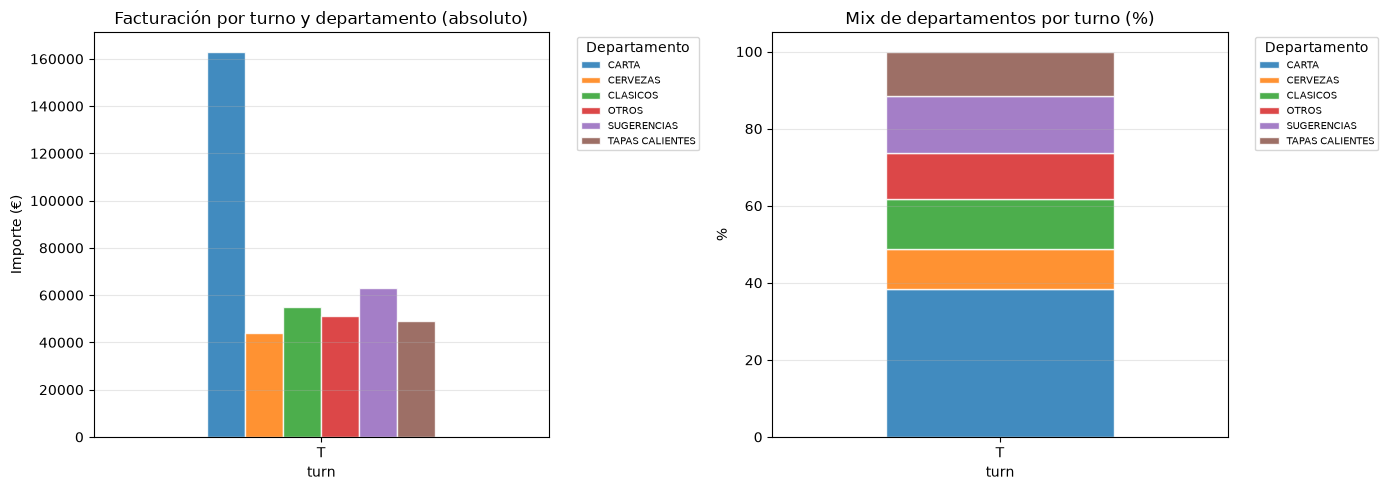

In [33]:
# ¿Qué departamentos dominan en comida vs cena?
mix_turno = (
    df_ventas_op[df_ventas_op['department_name'].isin(top6_deptos)]
    .groupby(['turn', 'department_name'])['amount']
    .sum()
    .unstack(fill_value=0)
)

mix_turno_pct = mix_turno.div(mix_turno.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mix_turno.plot(kind='bar', ax=axes[0], edgecolor='white', alpha=0.85)
axes[0].set_title('Facturación por turno y departamento (absoluto)')
axes[0].set_ylabel('Importe (€)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Departamento', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axes[0].grid(axis='y', alpha=0.3)

mix_turno_pct.plot(kind='bar', stacked=True, ax=axes[1], edgecolor='white', alpha=0.85)
axes[1].set_title('Mix de departamentos por turno (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Departamento', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'producto_mix_turno.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Análisis de propinas (tips)
- Distribución del importe de propina
- Relación propina / importe ticket (ratio)
- Variación por turno o día de la semana si está disponible vía `document_id`

In [34]:
df_tips[df_tips['flag_tip_anomala']] # Anomalía: propina > consumición

,source_file,report_start,report_end,report_generated_on,terminal_start,terminal_end,turn,document_id,document_amount,tip,document_total,flag_tip_anomala
1263,PROPINAS_TICKET.xls,2025-01-01,2026-07-07,2026-07-07,1 LA ROCA POZUELO,1 LA ROCA POZUELO,T,00001TM00005062,2.95,5.0,7.95,True


In [35]:
print(f"Total registros de propinas : {len(df_tips):,}")
print(f"Propinas anómalas (flag)    : {df_tips['flag_tip_anomala'].sum():,} "
      f"({df_tips['flag_tip_anomala'].mean()*100:.1f}%)")
print(f"\nTurnos: {df_tips['turn'].unique()}")
print(f"\nEstadísticas generales:")
display(df_tips[['document_amount','tip','document_total']].describe().round(2))

Total registros de propinas : 1,697
Propinas anómalas (flag)    : 1 (0.1%)

Turnos: <ArrowStringArray>
['T']
Length: 1, dtype: str

Estadísticas generales:


,document_amount,tip,document_total
count,1697.00,1697.00,1697.00
mean,129.00,4.93,133.93
std,95.74,4.79,98.68
min,2.35,0.01,3.00
25%,71.25,2.30,75.00
50%,103.15,3.85,107.00
75%,161.40,6.00,166.00
max,1365.00,70.00,1435.00


In [36]:
# Excluimos propinas anómalas para el análisis principal
# (las conservamos para mencionarlas pero no distorsionan la distribución)
df_tips_ok = df_tips[~df_tips['flag_tip_anomala']].copy()

# Ratio propina / importe base
df_tips_ok['ratio_propina'] = df_tips_ok['tip'] / df_tips_ok['document_amount'] * 100

print(f"Registros tras excluir anómalos: {len(df_tips_ok):,}")
print()
print("Estadísticas de propina (€):")
display(df_tips_ok['tip'].describe().round(3).to_frame().T)
print("\nEstadísticas de ratio propina/ticket (%):")
display(df_tips_ok['ratio_propina'].describe().round(3).to_frame().T)

Registros tras excluir anómalos: 1,696

Estadísticas de propina (€):


,count,mean,std,min,25%,50%,75%,max
tip,1696.0,4.929,4.791,0.01,2.3,3.85,6.0,70.0



Estadísticas de ratio propina/ticket (%):


,count,mean,std,min,25%,50%,75%,max
ratio_propina,1696.0,4.385,3.163,0.006,2.204,3.758,5.634,30.234


#### 5.1. Distribución de propinas

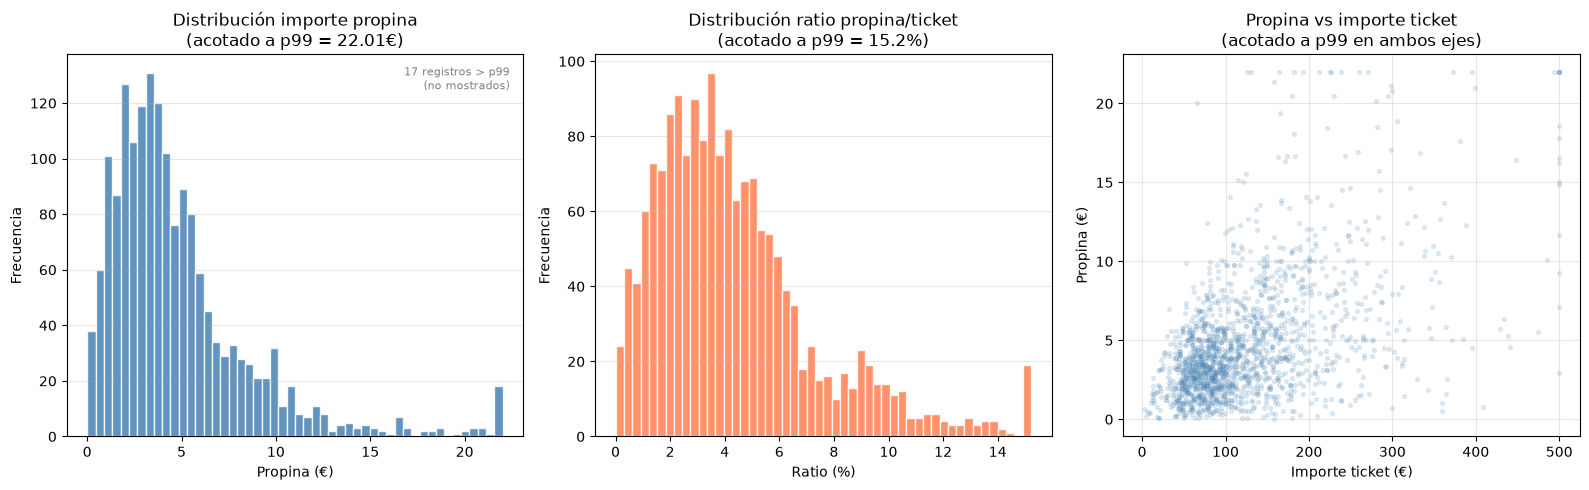

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel izquierdo: distribución del importe de propina
p99_tip = df_tips_ok['tip'].quantile(0.99)
axes[0].hist(df_tips_ok['tip'].clip(upper=p99_tip), bins=50,
             color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title(f'Distribución importe propina\n(acotado a p99 = {p99_tip:.2f}€)')
axes[0].set_xlabel('Propina (€)')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)
n_fuera = (df_tips_ok['tip'] > p99_tip).sum()
axes[0].text(0.97, 0.97, f'{n_fuera} registros > p99\n(no mostrados)',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=8, color='grey')

# Panel central: distribución del ratio (%)
p99_ratio = df_tips_ok['ratio_propina'].quantile(0.99)
axes[1].hist(df_tips_ok['ratio_propina'].clip(upper=p99_ratio), bins=50,
             color='coral', alpha=0.85, edgecolor='white')
axes[1].set_title(f'Distribución ratio propina/ticket\n(acotado a p99 = {p99_ratio:.1f}%)')
axes[1].set_xlabel('Ratio (%)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(axis='y', alpha=0.3)

# Panel derecho: scatter propina vs importe ticket
axes[2].scatter(df_tips_ok['document_amount'].clip(upper=500),
                df_tips_ok['tip'].clip(upper=p99_tip),
                alpha=0.15, s=8, color='steelblue')
axes[2].set_title('Propina vs importe ticket\n(acotado a p99 en ambos ejes)')
axes[2].set_xlabel('Importe ticket (€)')
axes[2].set_ylabel('Propina (€)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tips_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.2. Cruce con tickets

Propinas con fecha disponible (cruce con tickets): 1,695 de 1,696 (99.9%)

Estadísticas de propina por día de la semana:


,dia_semana,n_propinas,tip_media,ratio_medio,dia_es
0,Monday,13,5.792,5.477,Lunes
1,Tuesday,154,5.040,4.771,Martes
2,Wednesday,204,4.284,4.727,Miércoles
3,Thursday,248,5.290,5.008,Jueves
4,Friday,441,4.876,4.202,Viernes
5,Saturday,434,5.007,4.091,Sábado
6,Sunday,201,4.950,3.909,Domingo


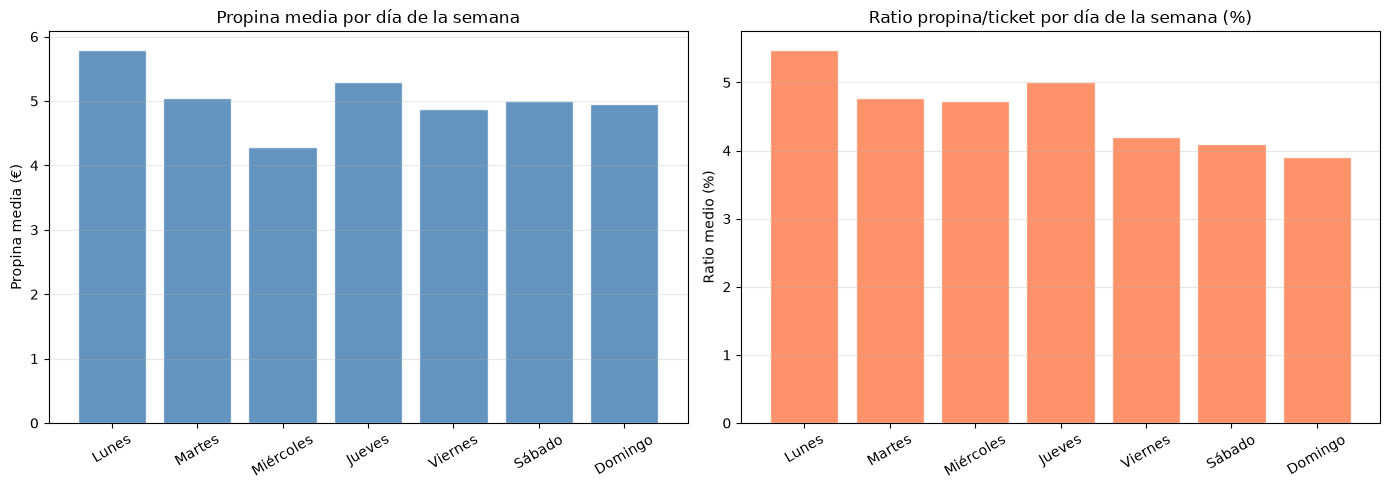

In [38]:
# df_tips tiene document_id para cruzar con df_tickets y obtener fecha/día semana
# Solo funciona para el período solapado (oct-25 en adelante)
# df_tips arranca en ene-25 pero df_tickets desde oct-25

fecha_por_ticket = df_tickets[['document_id','date']].drop_duplicates()

df_tips_fecha = df_tips_ok.merge(
    fecha_por_ticket,
    on='document_id',
    how='inner'  # solo los que tienen ticket en el período operativo
)

n_cruzados = len(df_tips_fecha)
print(f"Propinas con fecha disponible (cruce con tickets): {n_cruzados:,} "
      f"de {len(df_tips_ok):,} ({n_cruzados/len(df_tips_ok)*100:.1f}%)")

df_tips_fecha['dia_semana'] = pd.to_datetime(df_tips_fecha['date']).dt.day_name()
df_tips_fecha['num_dia']    = pd.to_datetime(df_tips_fecha['date']).dt.dayofweek

orden_dias  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
nombres_dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

stats_dia = (
    df_tips_fecha
    .groupby('dia_semana')
    .agg(
        n_propinas    = ('tip', 'count'),
        tip_media     = ('tip', 'mean'),
        ratio_medio   = ('ratio_propina', 'mean'),
    )
    .reindex(orden_dias)
    .reset_index()
)
stats_dia['dia_es'] = nombres_dias

print("\nEstadísticas de propina por día de la semana:")
display(stats_dia.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(stats_dia['dia_es'], stats_dia['tip_media'],
            color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title('Propina media por día de la semana')
axes[0].set_ylabel('Propina media (€)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(stats_dia['dia_es'], stats_dia['ratio_medio'],
            color='coral', alpha=0.85, edgecolor='white')
axes[1].set_title('Ratio propina/ticket por día de la semana (%)')
axes[1].set_ylabel('Ratio medio (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tips_por_dia_semana.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Variables externas: meteorología
- Temperatura y precipitación en el período de estudio
- Correlación visual (scatter / heatmap) entre variables meteo y facturación diaria
- ¿Hay efecto diferenciado entre días de lluvia y días secos?

In [39]:
df_meteo_diaria.info()
print(df_meteo_diaria.head(3).to_string())

<class 'pandas.DataFrame'>
RangeIndex: 1286 entries, 0 to 1285
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 1286 non-null   datetime64[ms]
 1   temperature_mean     1286 non-null   float64       
 2   temperature_max      1286 non-null   float64       
 3   temperature_min      1286 non-null   float64       
 4   precipitation_mm     1286 non-null   float64       
 5   rain_mm              1286 non-null   float64       
 6   precipitation_hours  1286 non-null   float64       
 7   wind_speed_max       1286 non-null   float64       
 8   sunshine_duration_s  1286 non-null   float64       
 9   sunshine_duration_h  1286 non-null   float64       
dtypes: datetime64[ms](1), float64(9)
memory usage: 100.6 KB
        date  temperature_mean  temperature_max  temperature_min  precipitation_mm  rain_mm  precipitation_hours  wind_speed_max  sunshine_duration_s  sunshine

#### 6.1. Join con facturación

In [40]:
# Filtramos meteo al período operativo (desde oct-25)
# para el análisis de correlación con facturación
FECHA_INICIO = pd.Timestamp('2025-10-01')

meteo_op = df_meteo_diaria[
    df_meteo_diaria['date'] >= FECHA_INICIO
].copy()

meteo_op['date'] = pd.to_datetime(meteo_op['date'])

print(f"Meteo completa  : {len(df_meteo_diaria):,} días "
      f"({df_meteo_diaria['date'].min().date()} → {df_meteo_diaria['date'].max().date()})")
print(f"Meteo operativa : {len(meteo_op):,} días "
      f"({meteo_op['date'].min().date()} → {meteo_op['date'].max().date()})")

# Join con ingresos_diarios (construido en sección 2)
ingresos_diarios['fecha'] = pd.to_datetime(ingresos_diarios['fecha'])

df_meteo_fact = meteo_op.merge(
    ingresos_diarios[['fecha','facturacion','num_tickets','ticket_medio']],
    left_on='date', right_on='fecha',
    how='inner'
).drop(columns='fecha')

print(f"\nDías con meteo + facturación: {len(df_meteo_fact):,}")
print(f"Días de meteo sin facturación (cierres): "
      f"{len(meteo_op) - len(df_meteo_fact):,}")

Meteo completa  : 1,286 días (2023-01-01 → 2026-07-09)
Meteo operativa : 282 días (2025-10-01 → 2026-07-09)

Días con meteo + facturación: 242
Días de meteo sin facturación (cierres): 40


#### 6.2. Evolución climática

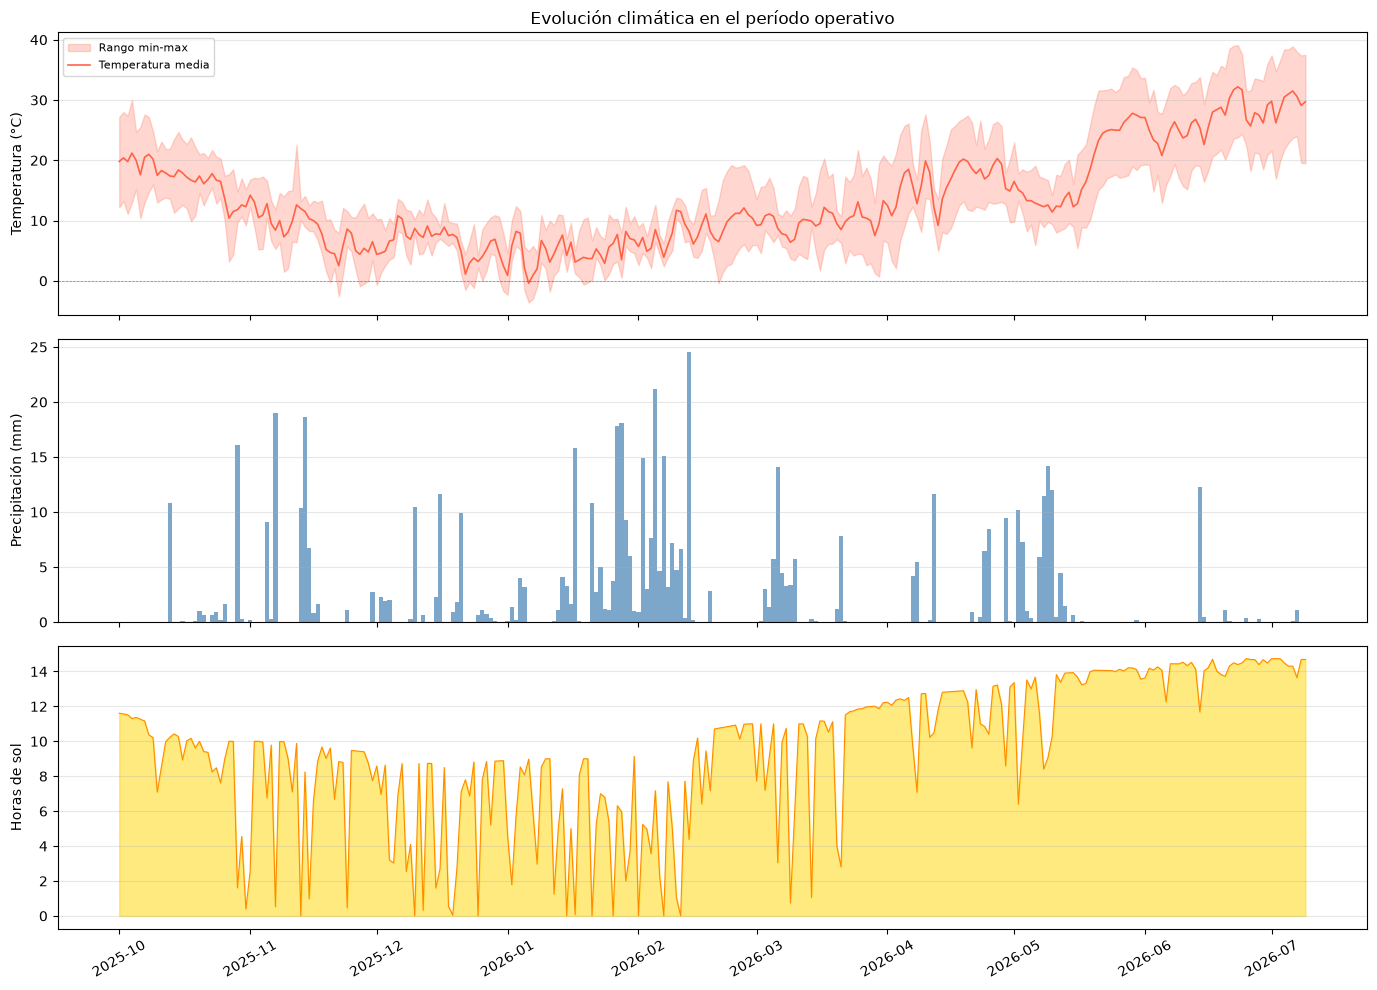

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: temperatura
axes[0].fill_between(meteo_op['date'],
                     meteo_op['temperature_min'],
                     meteo_op['temperature_max'],
                     alpha=0.25, color='tomato', label='Rango min-max')
axes[0].plot(meteo_op['date'], meteo_op['temperature_mean'],
             color='tomato', linewidth=1.2, label='Temperatura media')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Evolución climática en el período operativo')
axes[0].axhline(0, color='blue', linewidth=0.5, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: precipitación
axes[1].bar(meteo_op['date'], meteo_op['precipitation_mm'],
            color='steelblue', alpha=0.7, width=1)
axes[1].set_ylabel('Precipitación (mm)')
axes[1].grid(axis='y', alpha=0.3)

# Panel 3: horas de sol
axes[2].fill_between(meteo_op['date'], meteo_op['sunshine_duration_h'],
                     alpha=0.5, color='gold')
axes[2].plot(meteo_op['date'], meteo_op['sunshine_duration_h'],
             color='darkorange', linewidth=0.8)
axes[2].set_ylabel('Horas de sol')
axes[2].grid(axis='y', alpha=0.3)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'meteo_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()

#### 6.3. Correlación meteo x facturación

Correlación entre variables meteorológicas y facturación diaria:


,Pearson,Spearman
temperature_min,0.034,0.068
wind_speed_max,0.061,0.068
precipitation_hours,0.118,0.060
precipitation_mm,0.068,0.039
temperature_mean,0.014,0.028
temperature_max,-0.008,-0.005
sunshine_duration_h,-0.044,-0.003


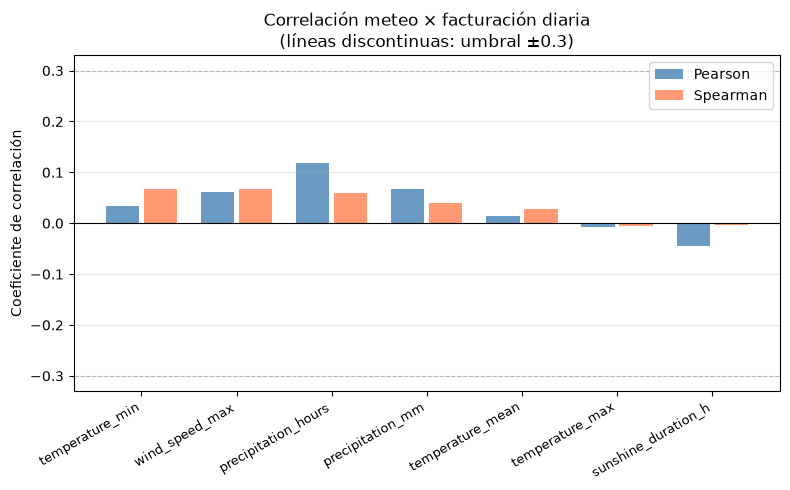

In [42]:
vars_meteo = [
    'temperature_max', 'temperature_min', 'temperature_mean',
    'precipitation_mm', 'precipitation_hours',
    'wind_speed_max', 'sunshine_duration_h'
]

# Correlaciones de Pearson y Spearman
correlaciones = pd.DataFrame({
    'Pearson' : [df_meteo_fact['facturacion'].corr(df_meteo_fact[v])
                 for v in vars_meteo],
    'Spearman': [df_meteo_fact['facturacion'].corr(df_meteo_fact[v], method='spearman')
                 for v in vars_meteo],
}, index=vars_meteo).round(3).sort_values('Spearman', key=abs, ascending=False)

print("Correlación entre variables meteorológicas y facturación diaria:")
display(correlaciones)

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(correlaciones))
ax.bar([i - 0.2 for i in x], correlaciones['Pearson'],
       width=0.35, label='Pearson', color='steelblue', alpha=0.8)
ax.bar([i + 0.2 for i in x], correlaciones['Spearman'],
       width=0.35, label='Spearman', color='coral', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(correlaciones.index, rotation=30, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.3,  color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(-0.3, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Correlación meteo × facturación diaria\n(líneas discontinuas: umbral ±0.3)')
ax.set_ylabel('Coeficiente de correlación')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'meteo_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

#### 6.4. Variables con mayor correlación

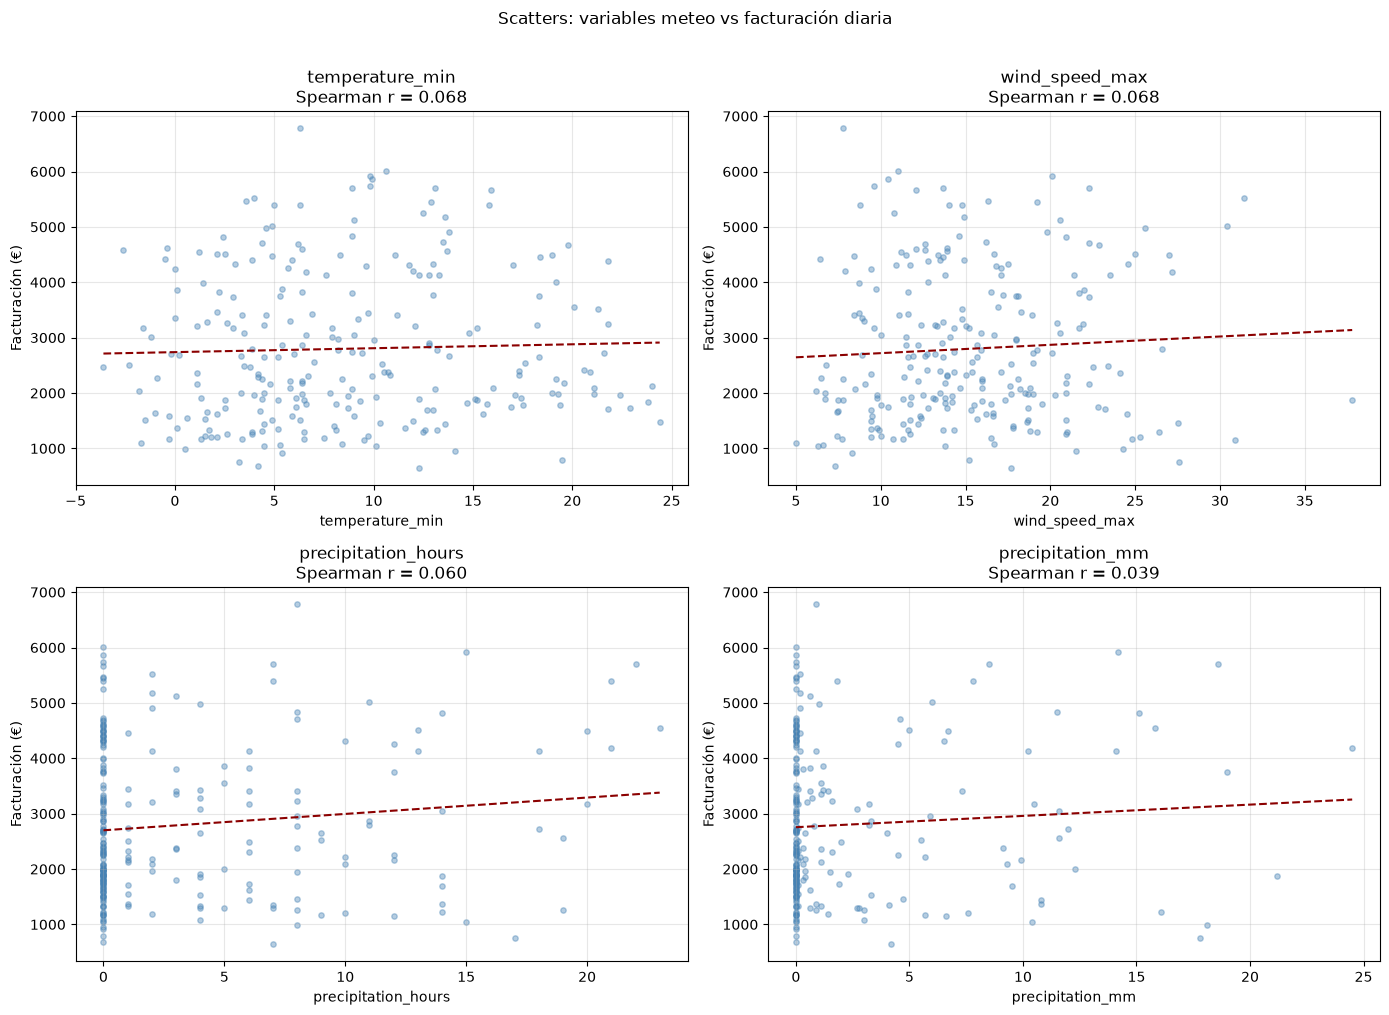

In [43]:
# Tomamos las 4 variables con mayor correlación absoluta (Spearman)
top4_vars = correlaciones['Spearman'].abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(top4_vars):
    axes[i].scatter(df_meteo_fact[var], df_meteo_fact['facturacion'],
                    alpha=0.4, s=15, color='steelblue')

    # Línea de tendencia
    z = np.polyfit(df_meteo_fact[var].dropna(),
                   df_meteo_fact.loc[df_meteo_fact[var].notna(), 'facturacion'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_meteo_fact[var].min(), df_meteo_fact[var].max(), 100)
    axes[i].plot(x_line, p(x_line), color='darkred', linewidth=1.5, linestyle='--')

    r_sp = correlaciones.loc[var, 'Spearman']
    axes[i].set_title(f'{var}\nSpearman r = {r_sp:.3f}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Facturación (€)')
    axes[i].grid(alpha=0.3)

plt.suptitle('Scatters: variables meteo vs facturación diaria', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'meteo_scatters.png', dpi=150, bbox_inches='tight')
plt.show()

#### 6.5. Efecto lluvia

Facturación según nivel de precipitación:


,n_días,media,mediana,std
cat_lluvia,,,,
Sin lluvia (0mm),136,2737.97,2341.18,1298.00
Lluvia leve (0-1mm),36,3032.01,2701.72,1404.17
Lluvia moderada (1-5mm),33,2540.97,2361.55,1187.76
Lluvia intensa (>5mm),37,3030.37,2714.70,1570.67


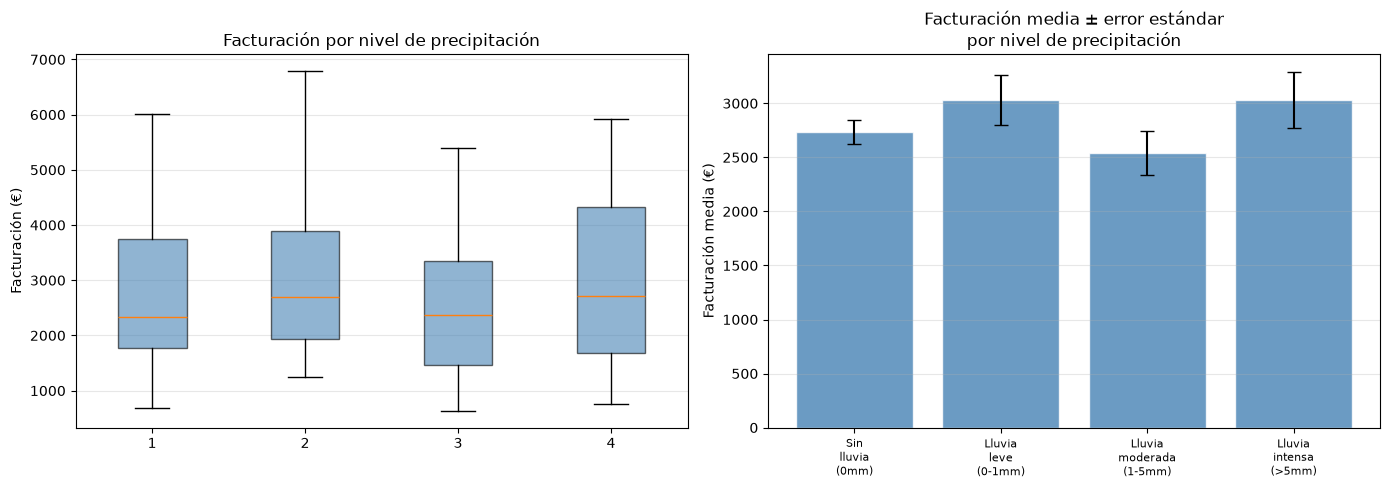

In [44]:
# Clasificamos días por nivel de precipitación
df_meteo_fact['cat_lluvia'] = pd.cut(
    df_meteo_fact['precipitation_mm'],
    bins=[-0.01, 0, 1, 5, 999],
    labels=['Sin lluvia (0mm)', 'Lluvia leve (0-1mm)',
            'Lluvia moderada (1-5mm)', 'Lluvia intensa (>5mm)']
)

stats_lluvia = (
    df_meteo_fact
    .groupby('cat_lluvia', observed=True)['facturacion']
    .agg(['count','mean','median','std'])
    .round(2)
)
stats_lluvia.columns = ['n_días','media','mediana','std']

print("Facturación según nivel de precipitación:")
display(stats_lluvia)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por categoría de lluvia
categorias = df_meteo_fact['cat_lluvia'].cat.categories.tolist()
data_box = [
    df_meteo_fact.loc[df_meteo_fact['cat_lluvia'] == c, 'facturacion'].values
    for c in categorias
]
axes[0].boxplot(data_box, label=[c.replace(' ', '\n') for c in categorias],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[0].set_title('Facturación por nivel de precipitación')
axes[0].set_ylabel('Facturación (€)')
axes[0].grid(axis='y', alpha=0.3)

# Media con intervalo de confianza aproximado (±1 std / sqrt(n))
medias  = stats_lluvia['media'].values
errores = (stats_lluvia['std'] / np.sqrt(stats_lluvia['n_días'])).values
axes[1].bar(range(len(categorias)), medias,
            yerr=errores, capsize=5,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_xticks(range(len(categorias)))
axes[1].set_xticklabels([c.replace(' ', '\n') for c in categorias], fontsize=8)
axes[1].set_title('Facturación media ± error estándar\npor nivel de precipitación')
axes[1].set_ylabel('Facturación media (€)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'meteo_efecto_lluvia.png', dpi=150, bbox_inches='tight')
plt.show()

#### 6.6. Efecto temperaturas cuartiles

Facturación según cuartil de temperatura:


,n_días,media,mediana,std
cuartil_temp,,,,
Frío (Q1),62,2794.48,2580.68,1340.13
Fresco (Q2),61,2762.55,2652.30,1372.45
Templado (Q3),58,2807.25,2318.50,1441.65
Calor (Q4),61,2834.40,2375.85,1263.95


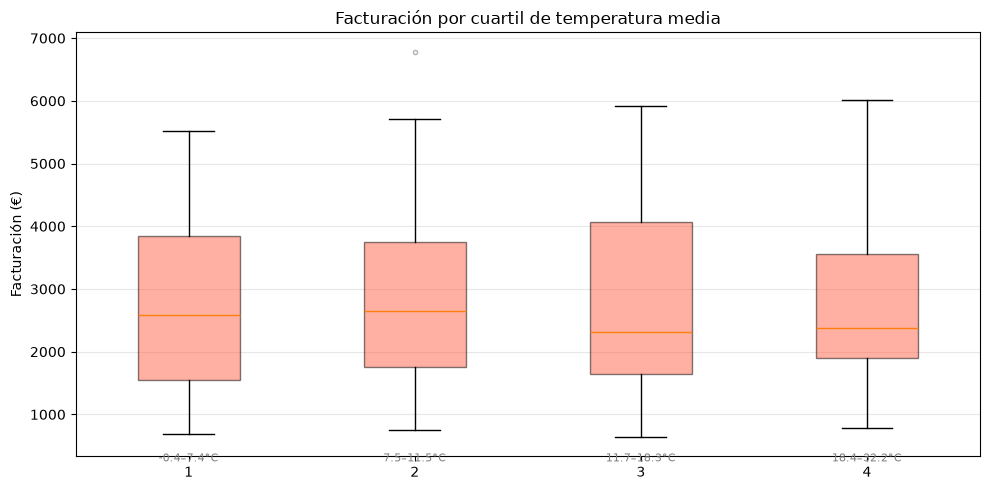

In [45]:
# Dividimos en quartiles de temperatura media
df_meteo_fact['cuartil_temp'] = pd.qcut(
    df_meteo_fact['temperature_mean'],
    q=4,
    labels=['Frío (Q1)', 'Fresco (Q2)', 'Templado (Q3)', 'Calor (Q4)']
)

stats_temp = (
    df_meteo_fact
    .groupby('cuartil_temp', observed=True)['facturacion']
    .agg(['count','mean','median','std'])
    .round(2)
)
stats_temp.columns = ['n_días','media','mediana','std']

print("Facturación según cuartil de temperatura:")
display(stats_temp)

fig, ax = plt.subplots(figsize=(10, 5))

categorias_t = df_meteo_fact['cuartil_temp'].cat.categories.tolist()
data_box_t = [
    df_meteo_fact.loc[df_meteo_fact['cuartil_temp'] == c, 'facturacion'].values
    for c in categorias_t
]
ax.boxplot(data_box_t, label=categorias_t, patch_artist=True,
           boxprops=dict(facecolor='tomato', alpha=0.5),
           flierprops=dict(marker='o', markersize=3, alpha=0.3))
ax.set_title('Facturación por cuartil de temperatura media')
ax.set_ylabel('Facturación (€)')
ax.grid(axis='y', alpha=0.3)

# Añadimos los rangos de temperatura de cada cuartil
rangos = df_meteo_fact.groupby('cuartil_temp', observed=True)['temperature_mean'].agg(['min','max']).round(1)
for i, (idx, row) in enumerate(rangos.iterrows()):
    ax.text(i+1, ax.get_ylim()[0] - 80,
            f'{row["min"]}–{row["max"]}°C',
            ha='center', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'meteo_efecto_temperatura.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Variables externas: festivos y eventos
- Distribución de facturación en días festivos vs. no festivos
- Comportamiento en fechas de eventos de alto impacto (Pozuelo, La Roca)
- Comparativa visual de medias: festivo vs. laborable, evento vs. sin evento

In [46]:
df_festivos.info()
print(df_festivos.head(3).to_string())
print("---")
df_eventos.info()
print(df_eventos.head(3).to_string())

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   fecha           56 non-null     datetime64[us]
 1   festivo_nombre  56 non-null     str           
 2   es_festivo      56 non-null     int64         
 3   dia_semana      56 non-null     str           
 4   nivel           56 non-null     str           
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 5.1 KB
       fecha              festivo_nombre  es_festivo dia_semana                nivel
0 2023-01-01                   Año Nuevo           1    Domingo  nacional_autonomico
1 2023-01-06          Epifanía del Señor           1    Viernes  nacional_autonomico
2 2023-03-20  Lunes siguiente a San José           1      Lunes  nacional_autonomico
---
<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dt

Preparamos los festivos, porque no todos caen en el período operativo en el que estamos trabajando (01-10-2025 --> 09-07-2026)

Tenemos que filtrarlos para quedarnos solo con los que nos aplican

In [47]:
df_festivos['fecha'] = pd.to_datetime(df_festivos['fecha'])
df_eventos['fecha_inicio'] = pd.to_datetime(df_eventos['fecha_inicio'])
df_eventos['fecha_fin']    = pd.to_datetime(df_eventos['fecha_fin'])

# Festivos en período operativo
festivos_op = df_festivos[
    df_festivos['fecha'] >= pd.Timestamp('2025-10-01')
].copy()

print(f"Festivos totales en dataset  : {len(df_festivos)}")
print(f"Festivos en período operativo: {len(festivos_op)}")
print()
print("Festivos en período operativo:")
display(festivos_op[['fecha','festivo_nombre','dia_semana']])

print(f"\nEventos en dataset (ya filtrado en Silver): {len(df_eventos)}")
print(f"\nDistribución por categoría:")
print(df_eventos['categoria'].value_counts())
print(f"\nDistribución por intensidad_sugerida:")
print(df_eventos['intensidad_sugerida'].value_counts().sort_index())
print(f"\nDistribución por dirección de demanda:")
print(df_eventos['direccion_demanda'].value_counts())

Festivos totales en dataset  : 56
Festivos en período operativo: 11

Festivos en período operativo:


,fecha,festivo_nombre,dia_semana
45,2025-11-01,Todos los Santos,Sábado
46,2025-11-10,Ntra. Sra. de la Almudena (festivo local Madri...,Lunes
47,2025-12-06,Día de la Constitución Española,Sábado
48,2025-12-08,Inmaculada Concepción,Lunes
49,2025-12-25,Natividad del Señor,Jueves
50,2026-01-01,Año Nuevo,Jueves
51,2026-01-06,Epifanía del Señor,Martes
52,2026-04-02,Jueves Santo,Jueves
53,2026-04-03,Viernes Santo,Viernes
54,2026-05-01,Fiesta del Trabajo,Viernes



Eventos en dataset (ya filtrado en Silver): 48

Distribución por categoría:
categoria
evento_local_cultural     13
calendario_social         12
calendario_escolar         7
fiesta_local               5
temporada_modelado         4
evento_local_comercial     4
calendario_comercial       2
evento_deportivo_local     1
Name: count, dtype: int64

Distribución por intensidad_sugerida:
intensidad_sugerida
-2     1
-1     1
 0     6
 1    17
 2    17
 3     6
Name: count, dtype: int64

Distribución por dirección de demanda:
direccion_demanda
aumenta      33
mixto        13
disminuye     2
Name: count, dtype: int64


`df_eventos` tiene eventos de duración variable (`fecha_inicio` → `fecha_fin`) — hay que expandirlos a granularidad diaria para poder cruzarlos con la tabla de facturación.

In [48]:
# Los eventos tienen duración variable (fecha_inicio → fecha_fin)
# Los expandimos a días individuales para cruzar con facturación diaria

registros = []
for _, row in df_eventos.iterrows():
    rango = pd.date_range(start=row['fecha_inicio'], end=row['fecha_fin'], freq='D')
    for fecha in rango:
        registros.append({
            'fecha'              : fecha,
            'event_id'           : row['event_id'],
            'nombre_evento'      : row['nombre_evento'],
            'categoria'          : row['categoria'],
            'intensidad_sugerida': row['intensidad_sugerida'],
            'impacto_esperado'   : row['impacto_esperado'],
            'direccion_demanda'  : row['direccion_demanda'],
            'proximidad_la_roca' : row['proximidad_la_roca'],
        })

df_eventos_diario = pd.DataFrame(registros)
df_eventos_diario['fecha'] = pd.to_datetime(df_eventos_diario['fecha'])

# Si un día tiene varios eventos, nos quedamos con el de mayor intensidad absoluta
# como representativo del día
df_eventos_diario['intensidad_abs'] = df_eventos_diario['intensidad_sugerida'].abs()

eventos_por_dia = (
    df_eventos_diario
    .sort_values('intensidad_abs', ascending=False)
    .groupby('fecha')
    .first()
    .reset_index()
    .drop(columns='intensidad_abs')
)

# Filtramos al período operativo
eventos_op = eventos_por_dia[
    eventos_por_dia['fecha'] >= pd.Timestamp('2025-10-01')
].copy()

print(f"Días únicos cubiertos por eventos (total dataset): {len(eventos_por_dia)}")
print(f"Días con evento en período operativo (oct-25 en adelante): {len(eventos_op)}")
print(f"\nDías cubiertos por periodo operativo sin evento: "
      f"{len(ingresos_diarios) - eventos_op['fecha'].isin(ingresos_diarios['fecha']).sum()}")

Días únicos cubiertos por eventos (total dataset): 229
Días con evento en período operativo (oct-25 en adelante): 229

Días cubiertos por periodo operativo sin evento: 114


Cruzamos los festivos con la facturación diaria

### Construcción de df_analisis

`df_analisis` es un DataFrame intermedio de granularidad diaria que extiende
`ingresos_diarios` con las variables de contexto externo (festivos y eventos).
No es un output final — es la base sobre la que se construirá la tabla maestra
gold en la sección 8, donde se añadirán también las variables de reservas y
meteorología.

| Origen | Variables añadidas |
|---|---|
| `ingresos_diarios` | `facturacion`, `num_tickets`, `ticket_medio`, `ticket_mediano`, `dia_semana`, `num_dia`, `mes` |
| `df_festivos` | `es_festivo`, `festivo_nombre` |
| `df_eventos` (expandido a días) | `tiene_evento`, `intensidad_evento`, `impacto_evento`, `direccion_evento`, `categoria_evento`, `cat_evento` |

In [49]:
ingresos_diarios['fecha'] = pd.to_datetime(ingresos_diarios['fecha'])

df_analisis = ingresos_diarios.copy()

# Flag festivo
df_analisis['es_festivo'] = df_analisis['fecha'].isin(
    festivos_op['fecha']
).astype(int)

df_analisis['festivo_nombre'] = df_analisis['fecha'].map(
    festivos_op.set_index('fecha')['festivo_nombre']
).fillna('')

# Flag y variables de evento
df_analisis['tiene_evento']      = df_analisis['fecha'].isin(
    eventos_op['fecha']
).astype(int)

df_analisis['intensidad_evento'] = df_analisis['fecha'].map(
    eventos_op.set_index('fecha')['intensidad_sugerida']
).fillna(0).astype(int)

df_analisis['impacto_evento']    = df_analisis['fecha'].map(
    eventos_op.set_index('fecha')['impacto_esperado']
).fillna('sin_evento')

df_analisis['direccion_evento']  = df_analisis['fecha'].map(
    eventos_op.set_index('fecha')['direccion_demanda']
).fillna('sin_evento')

df_analisis['categoria_evento']  = df_analisis['fecha'].map(
    eventos_op.set_index('fecha')['categoria']
).fillna('sin_evento')

print(f"Días totales en análisis   : {len(df_analisis)}")
print(f"Días festivos              : {df_analisis['es_festivo'].sum()}")
print(f"Días con evento            : {df_analisis['tiene_evento'].sum()}")
print(f"Días festivo Y evento      : "
      f"{((df_analisis['es_festivo']==1) & (df_analisis['tiene_evento']==1)).sum()}")
print(f"Días sin festivo ni evento : "
      f"{((df_analisis['es_festivo']==0) & (df_analisis['tiene_evento']==0)).sum()}")

Días totales en análisis   : 242
Días festivos              : 10
Días con evento            : 128
Días festivo Y evento      : 10
Días sin festivo ni evento : 114


Facturación según festivo:


,n_días,media,mediana,std
No festivo,232,2787.75,2382.9,1344.71
Festivo,10,3073.40,2819.4,1436.14


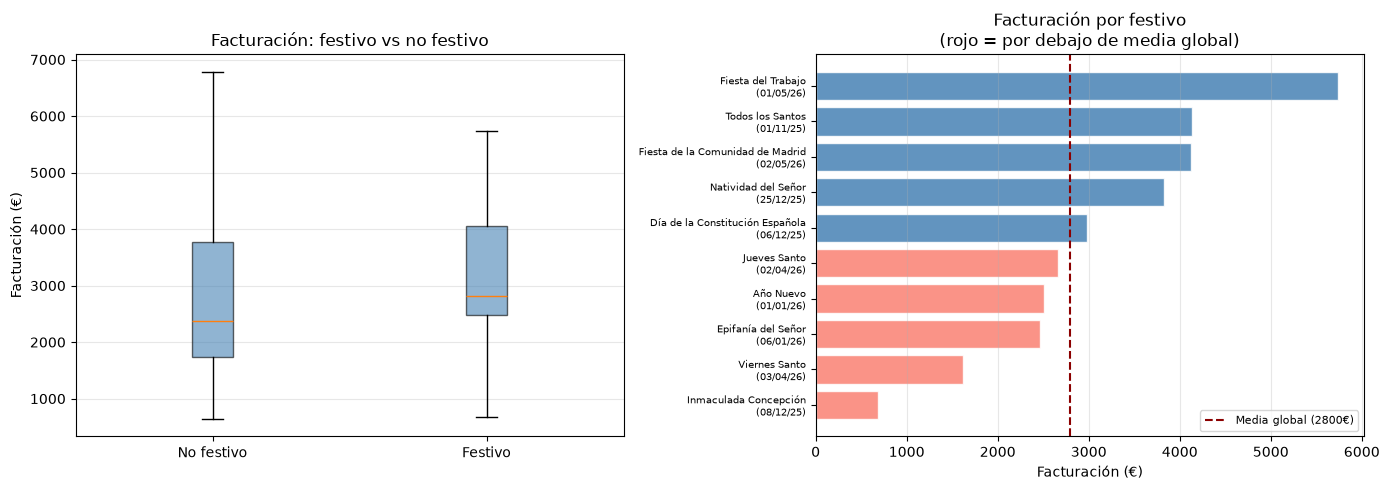

In [50]:
stats_festivo = (
    df_analisis
    .groupby('es_festivo')['facturacion']
    .agg(['count','mean','median','std'])
    .round(2)
)
stats_festivo.index = ['No festivo', 'Festivo']
stats_festivo.columns = ['n_días','media','mediana','std']

print("Facturación según festivo:")
display(stats_festivo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot festivo vs no festivo
data_fest = [
    df_analisis.loc[df_analisis['es_festivo']==0, 'facturacion'].values,
    df_analisis.loc[df_analisis['es_festivo']==1, 'facturacion'].values,
]
axes[0].boxplot(data_fest, tick_labels=['No festivo', 'Festivo'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                flierprops=dict(marker='o', markersize=4, alpha=0.4))
axes[0].set_title('Facturación: festivo vs no festivo')
axes[0].set_ylabel('Facturación (€)')
axes[0].grid(axis='y', alpha=0.3)

# Detalle por festivo individual vs media global
festivos_con_fact = df_analisis[df_analisis['es_festivo']==1].sort_values('facturacion')
media_global = df_analisis['facturacion'].mean()

if len(festivos_con_fact) > 0:
    colores = ['salmon' if v < media_global else 'steelblue'
               for v in festivos_con_fact['facturacion']]
    axes[1].barh(
        festivos_con_fact['festivo_nombre'] + '\n(' +
        festivos_con_fact['fecha'].dt.strftime('%d/%m/%y') + ')',
        festivos_con_fact['facturacion'],
        color=colores, alpha=0.85, edgecolor='white'
    )
    axes[1].axvline(media_global, color='darkred', linestyle='--',
                    linewidth=1.5, label=f'Media global ({media_global:.0f}€)')
    axes[1].set_title('Facturación por festivo\n(rojo = por debajo de media global)')
    axes[1].set_xlabel('Facturación (€)')
    axes[1].legend(fontsize=8)
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eventos_festivos.png', dpi=150, bbox_inches='tight')
plt.show()

Facturación según intensidad de evento:


,n_días,media,mediana,std
cat_evento,,,,
Sin evento,114,2576.06,1997.78,1416.58
Ambiguo / mixto,8,2577.66,2565.80,773.08
Intensidad baja,13,2735.45,2179.55,1268.48
Intensidad media,85,2989.52,2667.55,1240.50
Intensidad alta,22,3342.29,3093.82,1411.74


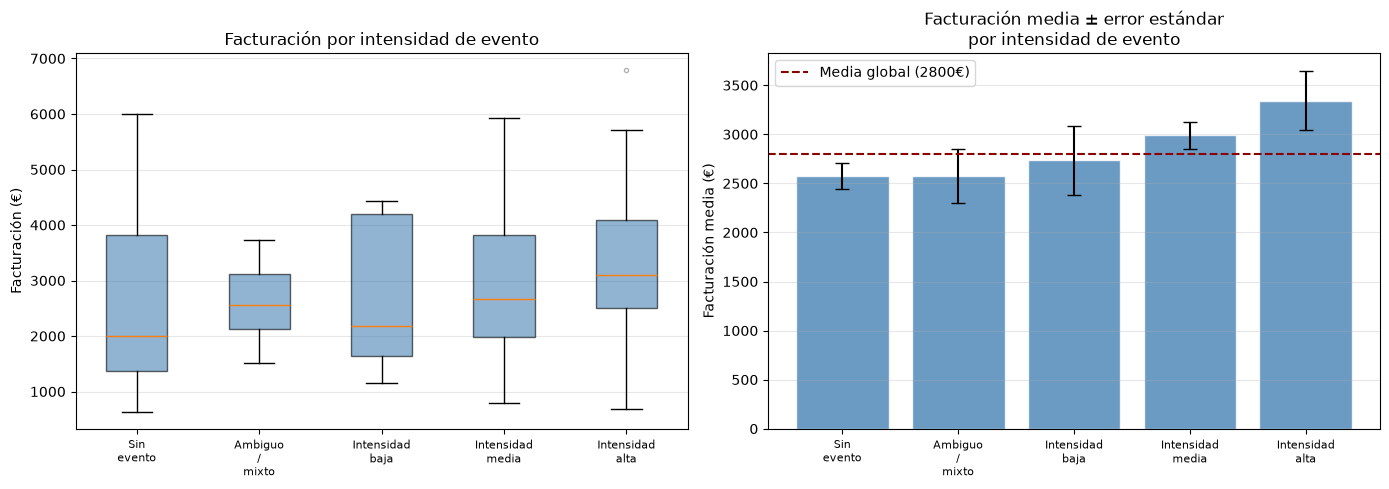

In [51]:
def categorizar_evento(x):
    if x == -2: return 'Impacto negativo alto'
    if x == -1: return 'Impacto negativo bajo'
    if x ==  0: return 'Ambiguo / mixto'
    if x ==  1: return 'Intensidad baja'
    if x ==  2: return 'Intensidad media'
    if x ==  3: return 'Intensidad alta'
    return 'Sin evento'

orden_cats = [
    'Sin evento', 'Impacto negativo alto', 'Impacto negativo bajo',
    'Ambiguo / mixto', 'Intensidad baja', 'Intensidad media', 'Intensidad alta'
]

def categorizar_dia(row):
    if row['tiene_evento'] == 0:
        return 'Sin evento'
    return categorizar_evento(row['intensidad_evento'])

df_analisis['cat_evento'] = pd.Categorical(
    df_analisis.apply(categorizar_dia, axis=1),
    categories=orden_cats,
    ordered=True
)

# Eliminamos categorías sin observaciones para no distorsionar el gráfico
cats_presentes = [c for c in orden_cats
                  if c in df_analisis['cat_evento'].values]

stats_evento = (
    df_analisis
    .groupby('cat_evento', observed=True)['facturacion']
    .agg(['count','mean','median','std'])
    .round(2)
)
stats_evento.columns = ['n_días','media','mediana','std']

print("Facturación según intensidad de evento:")
display(stats_evento)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_box_ev = [
    df_analisis.loc[df_analisis['cat_evento']==c, 'facturacion'].values
    for c in cats_presentes
]
axes[0].boxplot(data_box_ev,
                tick_labels=[c.replace(' ', '\n') for c in cats_presentes],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[0].set_title('Facturación por intensidad de evento')
axes[0].set_ylabel('Facturación (€)')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', labelsize=8)

medias_ev  = stats_evento.loc[cats_presentes, 'media'].values
errores_ev = (stats_evento.loc[cats_presentes, 'std'] /
              np.sqrt(stats_evento.loc[cats_presentes, 'n_días'])).values
axes[1].bar(range(len(cats_presentes)), medias_ev,
            yerr=errores_ev, capsize=5,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axhline(df_analisis['facturacion'].mean(), color='darkred',
                linestyle='--', linewidth=1.5, label=f'Media global ({media_global:.0f}€)')
axes[1].set_xticks(range(len(cats_presentes)))
axes[1].set_xticklabels([c.replace(' ', '\n') for c in cats_presentes], fontsize=8)
axes[1].set_title('Facturación media ± error estándar\npor intensidad de evento')
axes[1].set_ylabel('Facturación media (€)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eventos_intensidad.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# ADVERTENCIA METODOLÓGICA:
# La comparativa festivo/evento vs sin-festivo/sin-evento está contaminada
# por el efecto día de la semana. Un festivo en viernes parecerá tener
# alta facturación simplemente por ser viernes, no por ser festivo.
# Controlamos comparando dentro del mismo día de la semana.

df_analisis['dia_semana'] = pd.to_datetime(df_analisis['fecha']).dt.day_name()

# Festivos: comparativa dentro del mismo día de semana
comparativa_festivo = (
    df_analisis
    .groupby(['dia_semana','es_festivo'])['facturacion']
    .agg(['mean','count'])
    .round(2)
    .unstack()
)
comparativa_festivo.columns = ['media_no_festivo','media_festivo',
                                'n_no_festivo','n_festivo']

print("Facturación media por día de semana: festivo vs no festivo")
print("(NaN = sin observaciones en esa combinación)")
display(comparativa_festivo)

# Eventos: comparativa dentro del mismo día de semana
comparativa_evento = (
    df_analisis
    .groupby(['dia_semana','tiene_evento'])['facturacion']
    .agg(['mean','count'])
    .round(2)
    .unstack()
)
comparativa_evento.columns = ['media_sin_evento','media_con_evento',
                               'n_sin_evento','n_con_evento']

print("\nFacturación media por día de semana: con evento vs sin evento")
display(comparativa_evento)

Facturación media por día de semana: festivo vs no festivo
(NaN = sin observaciones en esa combinación)


,media_no_festivo,media_festivo,n_no_festivo,n_festivo
dia_semana,,,,
Friday,4401.59,3677.68,38.0,2.0
Monday,1980.56,681.75,4.0,1.0
Saturday,4404.91,3745.11,37.0,3.0
Sunday,2349.78,NaN,40.0,NaN
Thursday,2146.15,2997.58,38.0,3.0
Tuesday,1712.67,2468.85,36.0,1.0
Wednesday,1830.59,NaN,39.0,NaN



Facturación media por día de semana: con evento vs sin evento


,media_sin_evento,media_con_evento,n_sin_evento,n_con_evento
dia_semana,,,,
Friday,4525.74,4246.88,17.0,23.0
Monday,NaN,1720.80,NaN,5.0
Saturday,4576.42,4208.08,16.0,24.0
Sunday,2391.06,2322.26,16.0,24.0
Thursday,1902.11,2563.17,22.0,19.0
Tuesday,1384.36,2190.82,21.0,16.0
Wednesday,1560.71,2179.85,22.0,17.0


#### Conclusiones — Sección 7

**Festivos: efecto heterogéneo y dependiente del día de la semana**
Se identifican 10 festivos con actividad en el período operativo (6 festivos
de 2025 quedan fuera del período o coinciden con lunes de cierre). El efecto
sobre la facturación no es uniforme: los festivos que caen en viernes o
sábado mantienen facturaciones elevadas (Fiesta del Trabajo 5.800€, Todos
los Santos 4.200€, Fiesta de la Comunidad 4.100€), mientras que los que
caen en días laborables muestran facturaciones por debajo de la media global
(Inmaculada Concepción 800€, Viernes Santo 1.600€, Año Nuevo 2.500€).

La tabla de control por día de semana confirma este efecto: los festivos en
viernes facturan de media 724€ menos que los viernes no festivos (3.678€
vs 4.402€), y los festivos en sábado también rinden por debajo (3.745€ vs
4.405€). La interpretación es que los festivos no generan demanda adicional
— al contrario, parte de la clientela habitual está fuera de la ciudad.
Los festivos en días laborables (jueves, martes) sí muestran una ligera
mejora respecto a su día de semana sin festivo, probablemente porque atraen
comidas familiares o de ocio que no ocurrirían en un día normal.

**Implicación para el modelo:** el festivo no debe tratarse como una variable
binaria simple. Lo correcto es interaccionarlo con el día de la semana:
`festivo × fin_de_semana` y `festivo × laborable` capturan efectos opuestos.

**Eventos: señal positiva pero débil**
El 53% de los días con actividad tienen al menos un evento asociado (128 de
242 días), lo que refleja la amplitud del calendario construido. Los días
sin evento y los días con eventos de intensidad baja o media muestran
facturaciones similares y por debajo de la media global, mientras que los
eventos de intensidad alta (San Valentín, Día de la Madre, Cabalgata de
Reyes, Campana de Navidad, Feria del Libro) sí superan la media.

La tabla de control por día de semana muestra que los eventos en días
laborables (martes, miércoles, jueves) tienen un efecto positivo claro
(+600-800€ respecto al mismo día sin evento), mientras que en fin de semana
el efecto es ligeramente negativo o nulo — el fin de semana ya factura alto
independientemente del evento.

**Limitación metodológica importante:** con 128 días con evento sobre 242
totales, y eventos de intensidad alta siendo solo 6, el número de
observaciones por categoría es demasiado pequeño para hacer inferencia
estadística robusta. Los resultados son indicativos, no concluyentes.
La validación empírica de la escala de intensidad queda pendiente de
ampliar el período de datos.

**Implicación para el modelo:** `intensidad_evento` como variable numérica
continua tiene más sentido que como categórica dado el número limitado de
observaciones. Considerar también una variable específica para eventos de
alta proximidad (`proximidad_la_roca ∈ {alta, muy_alta}`) que capture
el efecto local independientemente de la intensidad global.

### 8. Análisis cruzado: construcción de la tabla maestra diaria
Este paso es crítico porque es el que alimenta directamente el modelado. Se trata de unir en una sola tabla por día:

- Facturación diaria (de tickets/ventas)
- N.º reservas y comensales
- Variables meteo diarias
- Flag festivo / nombre festivo
- Flag evento / intensidad sugerida

Comprobar que no hay huecos temporales inesperados tras el cruce.

In [53]:
# Verificamos qué tenemos disponible para el join
print("ingresos_diarios:", ingresos_diarios.shape, 
      "| cols:", ingresos_diarios.columns.tolist())
print()
print("df_analisis:", df_analisis.shape,
      "| cols:", df_analisis.columns.tolist())
print()
print("meteo_op:", meteo_op.shape,
      "| cols:", meteo_op.columns.tolist())
print()
# reservas_diarias puede que haya dado error en la sección 3
try:
    print("reservas_diarias:", reservas_diarias.shape,
          "| cols:", reservas_diarias.columns.tolist())
except NameError:
    print("reservas_diarias: NO DISPONIBLE en memoria")

ingresos_diarios: (242, 8) | cols: ['fecha', 'num_tickets', 'facturacion', 'ticket_medio', 'ticket_mediano', 'dia_semana', 'num_dia', 'mes']

df_analisis: (242, 16) | cols: ['fecha', 'num_tickets', 'facturacion', 'ticket_medio', 'ticket_mediano', 'dia_semana', 'num_dia', 'mes', 'es_festivo', 'festivo_nombre', 'tiene_evento', 'intensidad_evento', 'impacto_evento', 'direccion_evento', 'categoria_evento', 'cat_evento']

meteo_op: (282, 10) | cols: ['date', 'temperature_mean', 'temperature_max', 'temperature_min', 'precipitation_mm', 'rain_mm', 'precipitation_hours', 'wind_speed_max', 'sunshine_duration_s', 'sunshine_duration_h']

reservas_diarias: (242, 9) | cols: ['fecha', 'n_reservas_cancelada', 'n_reservas_completada', 'n_reservas_liberada', 'n_reservas_no_show', 'comensales_cancelada', 'comensales_completada', 'comensales_liberada', 'comensales_no_show']


In [54]:
# ── Tabla maestra diaria ──────────────────────────────────────────────────────
# Punto de partida: df_analisis (facturación + festivos + eventos)
# df_analisis fue construido en la sección 7 (celda 3) como join de
# ingresos_diarios + flags de festivos y eventos.
# Aquí lo extendemos con reservas y meteorología para obtener
# la tabla maestra gold final.
# Join 1: reservas diarias
# Join 2: meteorología diaria
# Resultado: una fila por día operativo con todas las variables disponibles

df_gold = df_analisis.copy()
df_gold['fecha'] = pd.to_datetime(df_gold['fecha'])

# Join con reservas
reservas_diarias['fecha'] = pd.to_datetime(reservas_diarias['fecha'])

df_gold = df_gold.merge(reservas_diarias, on='fecha', how='left')

# Join con meteo
meteo_op['date'] = pd.to_datetime(meteo_op['date'])

df_gold = df_gold.merge(
    meteo_op.drop(columns=['sunshine_duration_s', 'rain_mm']),
    left_on='fecha', right_on='date',
    how='left'
).drop(columns='date')

# Columnas calculadas adicionales
df_gold['n_reservas_total']     = (df_gold['n_reservas_completada'] +
                                   df_gold['n_reservas_cancelada'] +
                                   df_gold['n_reservas_no_show'])
df_gold['tasa_no_show']         = (df_gold['n_reservas_no_show'] /
                                   df_gold['n_reservas_total'].replace(0, pd.NA) * 100).round(2)
df_gold['tasa_cancelacion']     = (df_gold['n_reservas_cancelada'] /
                                   df_gold['n_reservas_total'].replace(0, pd.NA) * 100).round(2)
df_gold['tasa_liberada']        = (df_gold['n_reservas_liberada'] /
                                   df_gold['n_reservas_total'].replace(0, pd.NA) * 100).round(2)
df_gold['es_fin_de_semana']     = df_gold['num_dia'].isin([4, 5]).astype(int)
df_gold['es_lunes']             = (df_gold['num_dia'] == 0).astype(int)

print(f"Tabla maestra: {df_gold.shape[0]} filas × {df_gold.shape[1]} columnas")
print(f"\nColumnas:")
for col in df_gold.columns:
    print(f"  {col:<30} {df_gold[col].dtype}")

Tabla maestra: 242 filas × 37 columnas

Columnas:
  fecha                          datetime64[us]
  num_tickets                    int64
  facturacion                    float64
  ticket_medio                   float64
  ticket_mediano                 float64
  dia_semana                     str
  num_dia                        int32
  mes                            int32
  es_festivo                     int64
  festivo_nombre                 str
  tiene_evento                   int64
  intensidad_evento              int64
  impacto_evento                 str
  direccion_evento               str
  categoria_evento               str
  cat_evento                     category
  n_reservas_cancelada           float64
  n_reservas_completada          float64
  n_reservas_liberada            float64
  n_reservas_no_show             float64
  comensales_cancelada           Int64
  comensales_completada          Int64
  comensales_liberada            Int64
  comensales_no_show             Int6

In [55]:
# ── Verificación de integridad del join ──────────────────────────────────────

print("=== VERIFICACIÓN DE INTEGRIDAD ===\n")

# 1. Filas
print(f"Filas esperadas (días con actividad) : 242")
print(f"Filas en tabla maestra               : {len(df_gold)}")
print()

# 2. Cobertura temporal
print(f"Período: {df_gold['fecha'].min().date()} → {df_gold['fecha'].max().date()}")
print()

# 3. Huecos temporales
rango = pd.date_range(df_gold['fecha'].min(), df_gold['fecha'].max(), freq='D')
dias_en_gold = pd.to_datetime(df_gold['fecha'])
huecos = rango.difference(dias_en_gold)
print(f"Días en el rango completo : {len(rango)}")
print(f"Días en tabla maestra     : {len(df_gold)}")
print(f"Días ausentes (cierres)   : {len(huecos)}")
print()

# 4. Nulos por columna
nulos = df_gold.isnull().sum()
nulos_presentes = nulos[nulos > 0]
if len(nulos_presentes) == 0:
    print("✓ Sin nulos en ninguna columna")
else:
    print("⚠️  Columnas con nulos:")
    display(nulos_presentes.to_frame('n_nulos'))
print()

# 5. Estadísticas básicas de la variable objetivo
print("Estadísticas de facturación diaria:")
display(df_gold['facturacion'].describe().round(2).to_frame().T)

=== VERIFICACIÓN DE INTEGRIDAD ===

Filas esperadas (días con actividad) : 242
Filas en tabla maestra               : 242

Período: 2025-10-02 → 2026-07-09

Días en el rango completo : 281
Días en tabla maestra     : 242
Días ausentes (cierres)   : 39

⚠️  Columnas con nulos:


,n_nulos
n_reservas_cancelada,3
n_reservas_completada,3
n_reservas_liberada,3
n_reservas_no_show,3
comensales_cancelada,3
comensales_completada,3
comensales_liberada,3
comensales_no_show,3
n_reservas_total,3
tasa_no_show,3



Estadísticas de facturación diaria:


,count,mean,std,min,25%,50%,75%,max
facturacion,242.0,2799.55,1346.66,637.9,1746.55,2440.93,3816.29,6785.2


In [56]:
# Los 3 días con nulos en reservas son días sin ninguna reserva registrada
# (servicio 100% walk-in). Imputamos a 0 — es el valor correcto, no un dato ausente.

cols_reservas = [
    'n_reservas_cancelada', 'n_reservas_completada', 'n_reservas_no_show',
    'n_reservas_liberada',
    'comensales_cancelada', 'comensales_completada', 'comensales_no_show',
    'comensales_liberada',
    'n_reservas_total', 'tasa_no_show', 'tasa_cancelacion', 'tasa_liberada'
]

# Verificamos qué días son antes de imputar
print("Días con nulos en reservas:")
display(df_gold[df_gold['n_reservas_total'].isna()][
    ['fecha', 'dia_semana', 'facturacion', 'num_tickets']
])

df_gold[cols_reservas] = df_gold[cols_reservas].fillna(0)

df_gold['festivo_nombre'] = df_gold['festivo_nombre'].replace('', 'sin_festivo')

# Verificación
print(df_gold['festivo_nombre'].value_counts())

# Verificación final
assert df_gold.isnull().sum().sum() == 0, "Aún quedan nulos en la tabla maestra"
print("\n✓ Sin nulos tras imputación")
print(f"✓ Tabla maestra lista: {df_gold.shape[0]} filas × {df_gold.shape[1]} columnas")

Días con nulos en reservas:


,fecha,dia_semana,facturacion,num_tickets
10,2025-10-13,Monday,1444.85,17
215,2026-06-08,Monday,1790.09,22
241,2026-07-09,Thursday,788.70,12


festivo_nombre
sin_festivo                         232
Todos los Santos                      1
Día de la Constitución Española       1
Inmaculada Concepción                 1
Natividad del Señor                   1
Año Nuevo                             1
Epifanía del Señor                    1
Jueves Santo                          1
Viernes Santo                         1
Fiesta del Trabajo                    1
Fiesta de la Comunidad de Madrid      1
Name: count, dtype: int64

✓ Sin nulos tras imputación
✓ Tabla maestra lista: 242 filas × 37 columnas


sin reservas registradas de ningún tipo — posible laguna de registro en días de baja actividad, no afecta al modelo por tratarse de 3 días sobre 242

In [57]:
print("Vista previa de la tabla maestra (primeras 3 filas):")
display(df_gold.head(3).T)

Vista previa de la tabla maestra (primeras 3 filas):


,0,1,2
fecha,2025-10-02 00:00:00,2025-10-03 00:00:00,2025-10-04 00:00:00
num_tickets,21,53,40
facturacion,1339.33,4498.5,4323.0
ticket_medio,63.777619,84.877358,108.075
ticket_mediano,65.3,74.15,97.375
dia_semana,Thursday,Friday,Saturday
num_dia,3,4,5
mes,10,10,10
es_festivo,0,0,0
festivo_nombre,sin_festivo,sin_festivo,sin_festivo


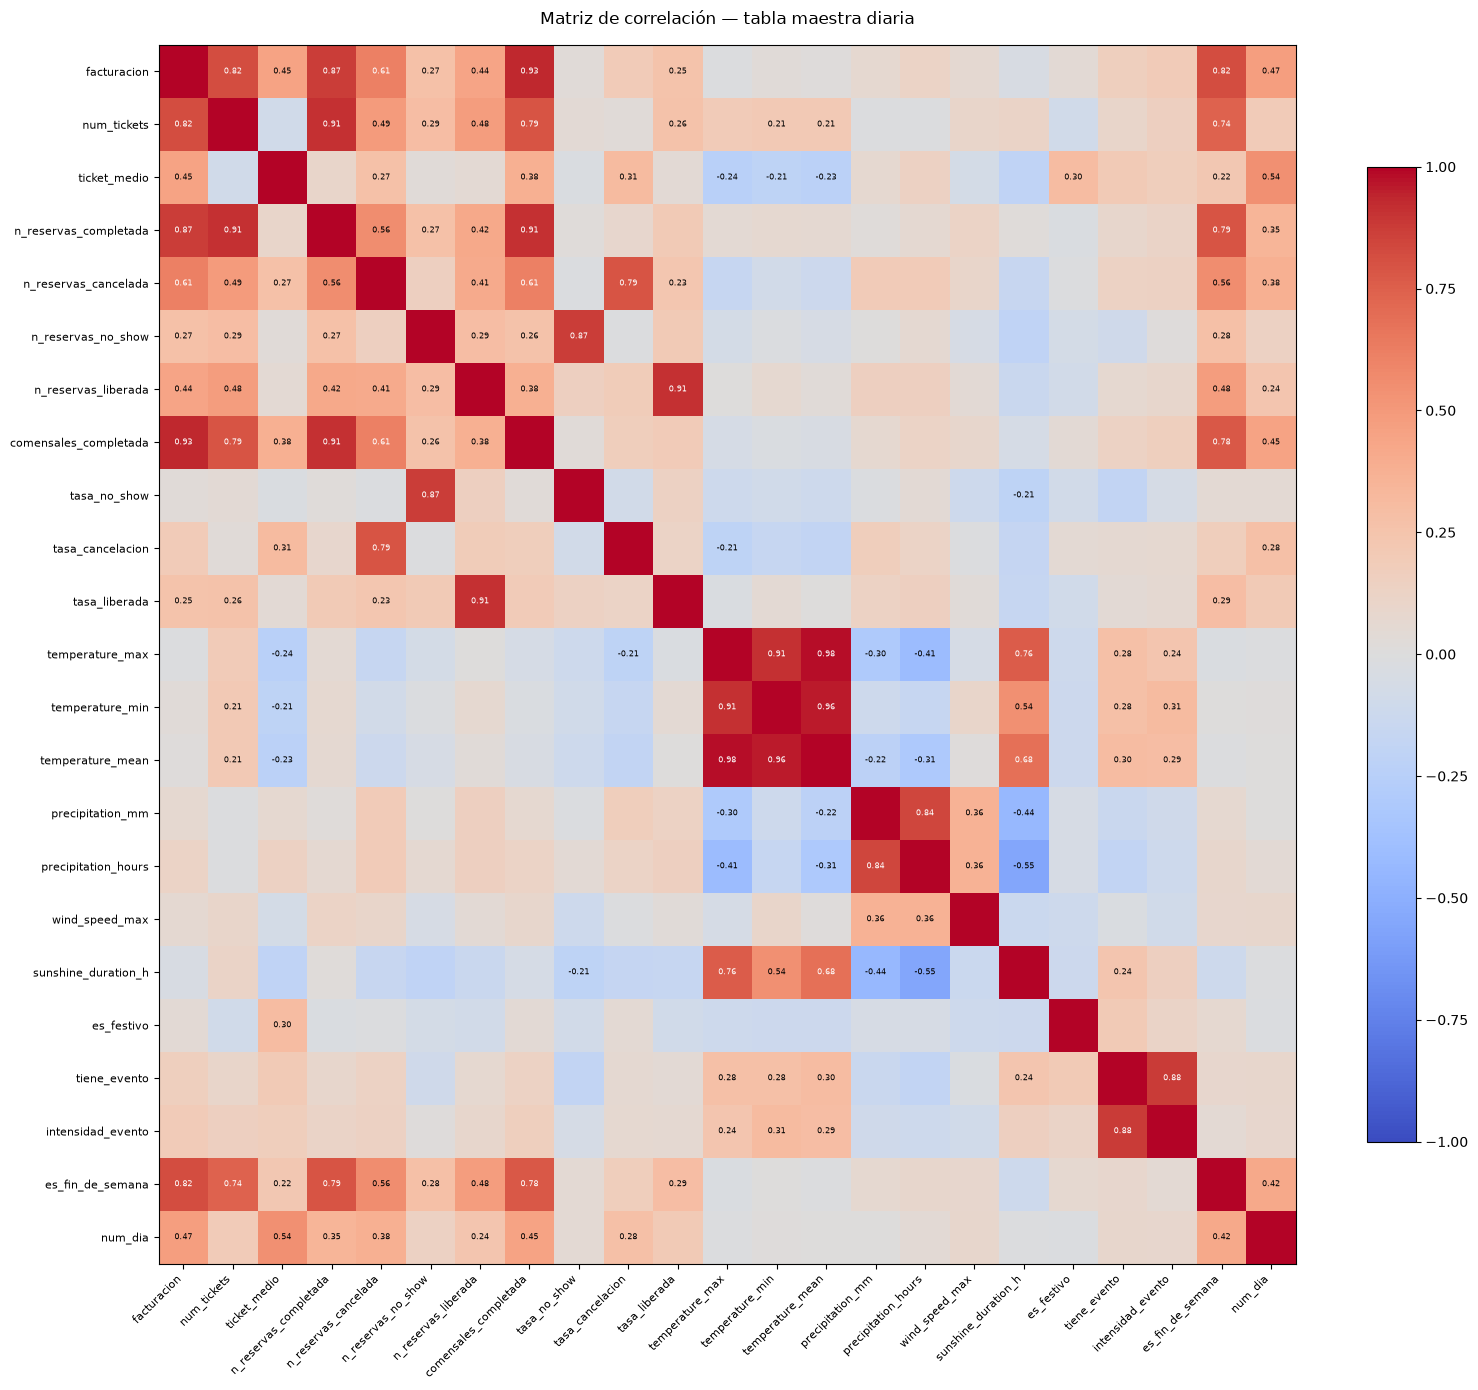

In [58]:
# Variables numéricas disponibles para el modelo
vars_numericas = [
    'facturacion', 'num_tickets', 'ticket_medio',
    'n_reservas_completada', 'n_reservas_cancelada', 'n_reservas_no_show', 'n_reservas_liberada',
    'comensales_completada', 'tasa_no_show', 'tasa_cancelacion', 'tasa_liberada',
    'temperature_max', 'temperature_min', 'temperature_mean',
    'precipitation_mm', 'precipitation_hours',
    'wind_speed_max', 'sunshine_duration_h',
    'es_festivo', 'tiene_evento', 'intensidad_evento',
    'es_fin_de_semana', 'num_dia'
]

# Matriz de correlación
corr_matrix = df_gold[vars_numericas].corr().round(2)

fig, ax = plt.subplots(figsize=(16, 14))

im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(range(len(vars_numericas)))
ax.set_yticks(range(len(vars_numericas)))
ax.set_xticklabels(vars_numericas, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(vars_numericas, fontsize=8)

# Anotaciones numéricas solo en celdas con correlación relevante (|r| > 0.2)
for i in range(len(vars_numericas)):
    for j in range(len(vars_numericas)):
        val = corr_matrix.values[i, j]
        if abs(val) > 0.2 and i != j:
            ax.text(j, i, f'{val:.2f}',
                    ha='center', va='center', fontsize=6,
                    color='white' if abs(val) > 0.6 else 'black')

ax.set_title('Matriz de correlación — tabla maestra diaria', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tabla_maestra_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
# Guardado en Gold
ruta_gold = GOLD_DIR / 'tabla_maestra_diaria.parquet'
df_gold.to_parquet(ruta_gold, index=False)
print(f"\n✓ Tabla maestra guardada en: {ruta_gold}")
print(f"  {df_gold.shape[0]:,} filas × {df_gold.shape[1]} columnas")


✓ Tabla maestra guardada en: /Users/laura/TFM-Hosteleria-AI/data/gold/tabla_maestra_diaria.parquet
  242 filas × 37 columnas


### 9. Correlaciones y selección preliminar de features
- Matriz de correlación entre facturación diaria y todas las variables numéricas disponibles
- Identificación de las variables con mayor correlación con la variable objetivo
- Primera reflexión sobre qué features tienen sentido para el modelo (justificada, no automática)

In [60]:
# Correlaciones de Pearson y Spearman con la variable objetivo
vars_modelo = [
    'num_tickets', 'ticket_medio',
    'n_reservas_completada', 'n_reservas_cancelada', 'n_reservas_no_show', 'n_reservas_liberada',
    'comensales_completada', 'tasa_no_show', 'tasa_cancelacion', 'tasa_liberada',
    'temperature_max', 'temperature_min', 'temperature_mean',
    'precipitation_mm', 'precipitation_hours',
    'wind_speed_max', 'sunshine_duration_h',
    'es_festivo', 'tiene_evento', 'intensidad_evento',
    'es_fin_de_semana', 'num_dia'
]

correlaciones_obj = pd.DataFrame({
    'Pearson' : [df_gold['facturacion'].corr(df_gold[v])
                 for v in vars_modelo],
    'Spearman': [df_gold['facturacion'].rank().corr(df_gold[v].rank())
                 for v in vars_modelo],
}, index=vars_modelo).round(3)

correlaciones_obj['abs_spearman'] = correlaciones_obj['Spearman'].abs()
correlaciones_obj = correlaciones_obj.sort_values('abs_spearman', ascending=False)

print("Correlación con facturación diaria (variable objetivo):")
display(correlaciones_obj.drop(columns='abs_spearman'))

Correlación con facturación diaria (variable objetivo):


,Pearson,Spearman
comensales_completada,0.935,0.937
n_reservas_completada,0.873,0.849
num_tickets,0.818,0.788
es_fin_de_semana,0.816,0.774
n_reservas_cancelada,0.605,0.582
ticket_medio,0.454,0.566
n_reservas_liberada,0.439,0.522
num_dia,0.468,0.504
tasa_liberada,0.251,0.428
intensidad_evento,0.187,0.229


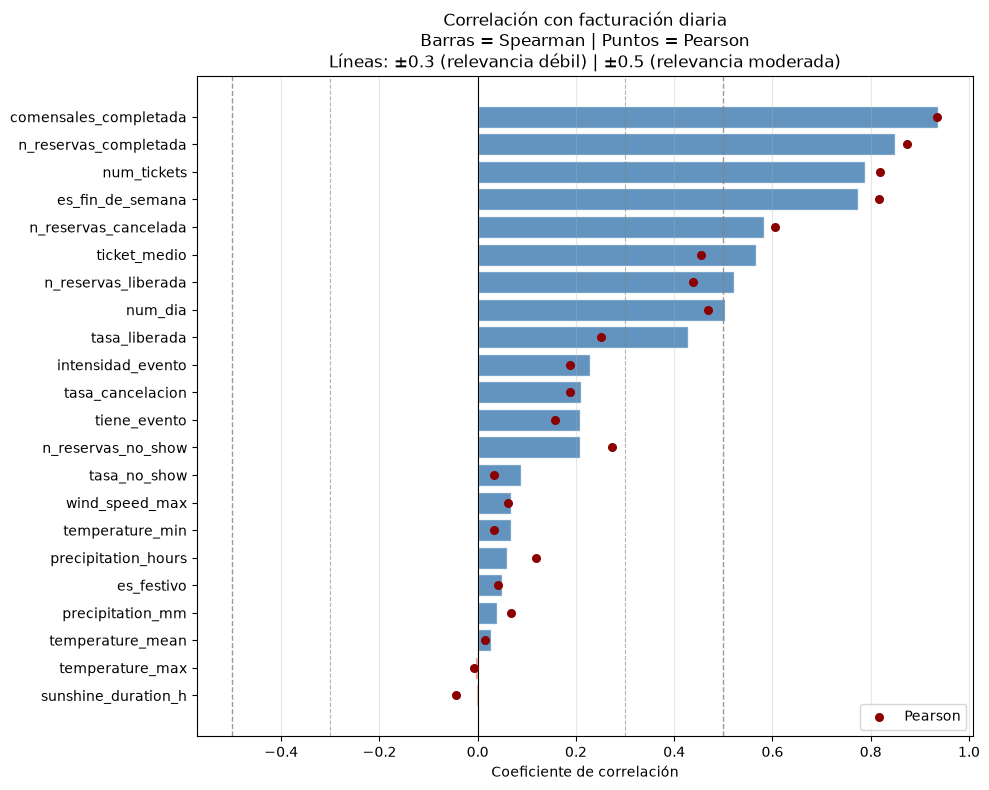

In [61]:
#Gráfico de correlaciones con la variable objetivo:

fig, ax = plt.subplots(figsize=(10, 8))

colores = ['steelblue' if v > 0 else 'salmon'
           for v in correlaciones_obj['Spearman']]

bars = ax.barh(correlaciones_obj.index[::-1],
               correlaciones_obj['Spearman'][::-1],
               color=colores[::-1], alpha=0.85, edgecolor='white')

# Pearson como puntos superpuestos
ax.scatter(correlaciones_obj['Pearson'][::-1],
           range(len(correlaciones_obj)),
           color='darkred', zorder=5, s=30, label='Pearson')

ax.axvline(0,    color='black', linewidth=0.8)
ax.axvline(0.3,  color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(-0.3, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(0.5,  color='grey', linewidth=1.0, linestyle='--', alpha=0.8)
ax.axvline(-0.5, color='grey', linewidth=1.0, linestyle='--', alpha=0.8)

ax.set_title('Correlación con facturación diaria\n'
             'Barras = Spearman | Puntos = Pearson\n'
             'Líneas: ±0.3 (relevancia débil) | ±0.5 (relevancia moderada)')
ax.set_xlabel('Coeficiente de correlación')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlaciones_objetivo.png', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
# Identificamos grupos de variables altamente correlacionadas entre sí
# para anticipar problemas de multicolinealidad en el modelado

umbral_multicol = 0.75
corr_features = df_gold[vars_modelo].corr().abs()

pares_multicol = []
for i in range(len(vars_modelo)):
    for j in range(i+1, len(vars_modelo)):
        r = corr_features.iloc[i, j]
        if r > umbral_multicol:
            pares_multicol.append({
                'var_1': vars_modelo[i],
                'var_2': vars_modelo[j],
                'correlacion': round(r, 3)
            })

df_multicol = pd.DataFrame(pares_multicol).sort_values('correlacion', ascending=False)
print(f"Pares de features con correlación > {umbral_multicol}:")
display(df_multicol)

Pares de features con correlación > 0.75:


,var_1,var_2,correlacion
9,temperature_max,temperature_mean,0.983
11,temperature_min,temperature_mean,0.965
2,n_reservas_completada,comensales_completada,0.915
6,n_reservas_liberada,tasa_liberada,0.915
0,num_tickets,n_reservas_completada,0.914
8,temperature_max,temperature_min,0.906
13,tiene_evento,intensidad_evento,0.880
5,n_reservas_no_show,tasa_no_show,0.871
12,precipitation_mm,precipitation_hours,0.844
1,num_tickets,comensales_completada,0.794


In [63]:
features_seleccion = {

    'ALTA PRIORIDAD — incluir en todos los modelos': [
        'es_fin_de_semana',     # Spearman 0.774 — feature más potente sin leakage
        'num_dia',              # Spearman 0.504 — captura gradiente lun→dom
        'n_reservas_cancelada', # Spearman 0.582 — disponible antes del servicio (asunción, ver nota)
        'tasa_cancelacion',     # Spearman 0.211 — señal anticipada de demanda (asunción, ver nota)
        'intensidad_evento',    # Spearman 0.229 — mejor que tiene_evento (redundante)
    ],

    'MEDIA PRIORIDAD — evaluar en feature engineering': [
        'es_festivo',          # Spearman 0.049 — señal débil pero interacción
                                # con día_semana puede ser relevante
        'precipitation_mm',    # Spearman 0.039 — señal débil individualmente
                                # pero potencialmente útil como binaria (llueve/no)
        'temperature_mean',    # Spearman 0.028 — sin señal directa; puede
                                # ser útil en interacción con fin de semana
    ],

    'EXCLUIR — data leakage (conocidas solo al cierre del día)': [
        'comensales_completada', # Spearman 0.937 — no disponible a priori
        'n_reservas_completada', # Spearman 0.849 — no disponible a priori
        'num_tickets',           # Spearman 0.788 — no disponible a priori
    ],

    'EXCLUIR — no se puede verificar disponibilidad antes del servicio': [
        'n_reservas_liberada',  # Spearman 0.522 — señal fuerte, pero el dataset no
                                 # tiene marca temporal del cambio de estado a 'liberada'.
                                 # antelacion_horas mide creación, no el momento en que se
                                 # liberó la mesa. No se puede demostrar que se conozca antes
                                 # del cierre del día, así que se trata como leakage por
                                 # defecto pese a no tener la certeza que sí hay en
                                 # comensales_completada/n_reservas_completada/num_tickets.
        'tasa_liberada',        # Spearman 0.428 — misma limitación que n_reservas_liberada
    ],

    'EXCLUIR — multicolinealidad (redundantes con variables ya incluidas)': [
        'temperature_max',     # r=0.983 con temperature_mean
        'temperature_min',     # r=0.965 con temperature_mean
        'sunshine_duration_h', # r=0.756 con temperature_max, sin señal propia
        'precipitation_hours', # r=0.844 con precipitation_mm
        'tiene_evento',        # r=0.880 con intensidad_evento
        'tasa_no_show',        # r=0.871 con n_reservas_no_show, señal débil
        'n_reservas_no_show',  # Spearman 0.208 — señal débil
        'ticket_medio',        # consecuencia, no causa
    ],
}

for grupo, vars_lista in features_seleccion.items():
    print(f"\n{'='*65}")
    print(f"{grupo}")
    print(f"{'='*65}")
    for v in vars_lista:
        r = correlaciones_obj.loc[v, 'Spearman'] if v in correlaciones_obj.index else 'N/A'
        print(f"  {v:<35} Spearman = {r}")


ALTA PRIORIDAD — incluir en todos los modelos
  es_fin_de_semana                    Spearman = 0.774
  num_dia                             Spearman = 0.504
  n_reservas_cancelada                Spearman = 0.582
  tasa_cancelacion                    Spearman = 0.211
  intensidad_evento                   Spearman = 0.229

MEDIA PRIORIDAD — evaluar en feature engineering
  es_festivo                          Spearman = 0.049
  precipitation_mm                    Spearman = 0.039
  temperature_mean                    Spearman = 0.028

EXCLUIR — data leakage (conocidas solo al cierre del día)
  comensales_completada               Spearman = 0.937
  n_reservas_completada               Spearman = 0.849
  num_tickets                         Spearman = 0.788

EXCLUIR — no se puede verificar disponibilidad antes del servicio
  n_reservas_liberada                 Spearman = 0.522
  tasa_liberada                       Spearman = 0.428

EXCLUIR — multicolinealidad (redundantes con variables ya inc

#### ⚠️ Advertencia: Data Leakage en variables de reservas

Las siguientes variables tienen correlación muy alta con la facturación
diaria pero **no están disponibles antes del día de servicio** — se
conocen únicamente al cierre del día. Usarlas directamente como features
provocaría data leakage y daría métricas artificialmente perfectas
en entrenamiento que no se reproducirían en producción.

| Variable | Spearman | Motivo de exclusión |
|---|---|---|
| `comensales_completada` | 0.937 | Se conoce al cierre del día |
| `n_reservas_completada` | 0.849 | Se conoce al cierre del día |
| `num_tickets` | 0.788 | Se conoce al cierre del día |

**Excepción:** `n_reservas_cancelada` y `tasa_cancelacion` sí son
utilizables como features porque las cancelaciones ocurren **antes**
del servicio y constituyen una señal anticipada de la demanda real esperada.

**Decisión para el modelado:**
- `comensales_completada` y `num_tickets`: excluir como features.
  Pueden usarse como **variable objetivo alternativa** (predecir
  ocupación en lugar de facturación).
- `n_reservas_completada`: usar únicamente en versión **T-1**
  (reservas confirmadas con antelación), nunca el valor del día.
  Esto se implementa en el notebook de feature engineering (`04_features.ipynb`).

#### Conclusiones correlaciones y selección de features

**El día de la semana domina absolutamente la varianza**
`es_fin_de_semana` (Spearman 0.774) y `num_dia` (0.504) son las variables
con mayor correlación con la facturación que están disponibles sin leakage.
La diferencia entre viernes/sábado (~4.360€) y lunes/martes/miércoles
(~1.760€) es de más del doble, y esta señal es tan potente que enmascara
el efecto de cualquier otra variable externa. Cualquier modelo que no
incorpore el día de la semana como feature primaria tendrá un rendimiento
muy bajo.

**Las variables de reservas tienen alta correlación pero presentan
riesgo de leakage**
`comensales_completada` (0.937), `n_reservas_completada` (0.849) y
`num_tickets` (0.788) son las variables más correlacionadas con la
facturación — pero las tres se conocen solo al cierre del día, no antes.
Usarlas directamente como features provocaría data leakage y daría métricas
artificialmente perfectas en entrenamiento. Deben excluirse como features
directas. La excepción es `n_reservas_cancelada` (0.582) y `tasa_cancelacion`
(0.211): las cancelaciones ocurren, por lógica de negocio, antes del
servicio, y constituyen una señal anticipada de demanda real esperada.

**Limitación: la disponibilidad temporal de `cancelada` no está verificada
con un dato explícito.** El dataset no registra el instante en que una
reserva cambia a estado `Cancelado por el cliente` — solo `created_datetime`
(creación) y `reservation_datetime` (fecha del servicio). Que la cancelación
se conozca antes del cierre del día es una asunción de lógica de negocio
razonable (no tiene sentido operativo "cancelar" después de haber comido),
pero no es un hecho verificado con una marca temporal, a diferencia de
`comensales_completada`/`n_reservas_completada`/`num_tickets`, cuya condición
de leakage sí es cierta por construcción.

**`Liberada` queda excluida por la misma limitación, con un resultado
distinto al no sostenerse la asunción de negocio.** `n_reservas_liberada`
(Spearman 0.522) y `tasa_liberada` (0.428) muestran una correlación con
la facturación superior a `num_dia` — sería, en principio, la segunda
señal anticipada más potente del dataset tras `es_fin_de_semana`. Sin
embargo, a diferencia de una cancelación, el significado operativo de
`Liberada` (mesa liberada al terminar el servicio) sugiere que el estado
podría fijarse el mismo día del servicio, no antes. El análisis de
antelación (ver `06_pred_noshows`) muestra que solo un 27.5% de los casos
tiene antelación casi nula (compatible con esa hipótesis); el resto se
distribuye con mediana de 1.85h y máximo de 1.231h, lo que no encaja con
un evento que ocurre exclusivamente al cierre. En ausencia de una marca
temporal del cambio de estado, no se puede demostrar que `liberada` se
conozca antes del servicio — se trata como leakage por precaución,
igual que las variables de la categoría anterior, aunque con menor
certeza que ellas.

**Las variables meteorológicas no tienen señal directa sobre facturación**
Ninguna variable meteorológica supera Spearman 0.07 con la facturación
diaria. La razón es clara: el efecto día de la semana domina tanto la
varianza que la señal meteorológica queda completamente enmascarada en
un análisis univariante. Esto no significa que la meteo sea irrelevante
— puede tener efecto condicional (lluvia en fin de semana vs lluvia en
martes). Su valor se evaluará en el feature engineering mediante
variables de interacción.

**Multicolinealidad severa entre grupos de variables**
Se identifican 14 pares con correlación > 0.75, agrupados en cinco
familias: temperaturas (max/min/mean, r > 0.96), precipitación
(mm/hours, r = 0.84), reservas completadas (n_reservas/comensales/
num_tickets, r > 0.79), eventos (tiene_evento/intensidad, r = 0.88) y
reservas liberadas (n_reservas_liberada/tasa_liberada, r = 0.915). En las
primeras cuatro familias se conserva una sola variable representativa
para el modelo: `temperature_mean`, `precipitation_mm`, `n_reservas_cancelada`
e `intensidad_evento` respectivamente. La familia de `liberada` no requiere
esa decisión: ambas variables quedan excluidas por el motivo anterior antes
de llegar a la pregunta de redundancia.

**Eventos y festivos: señal estadísticamente débil**
`intensidad_evento` (0.229) y `es_festivo` (0.049) muestran correlaciones
bajas con la facturación. Sin embargo, su utilidad no debe evaluarse
en términos univariantes — el análisis de la sección 7 mostró que su
efecto es heterogéneo según el día de la semana. En el feature engineering
se explorarán términos de interacción `festivo × fin_de_semana` e
`intensidad_evento × laborable`.

**Features seleccionadas para el modelado (resumen)**
Sin leakage y sin redundancias: `es_fin_de_semana`, `num_dia`,
`n_reservas_cancelada`, `tasa_cancelacion`, `intensidad_evento`,
`es_festivo`, `precipitation_mm`, `temperature_mean`. Quedan excluidas
`n_reservas_liberada` y `tasa_liberada` pese a su correlación relevante,
por no poder verificarse su disponibilidad antes del servicio. A las
seleccionadas se añadirán en feature engineering: variables lag de
facturación (t-7, t-14), variables de interacción día×festivo y
día×evento, y versión binaria de lluvia (`llueve`).

### 10. Conclusiones del EDA
Resumen breve y accionable: qué patrones se han encontrado, qué features parecen relevantes, qué limitaciones tiene el dato (cobertura temporal desde oct-2025, tamaño de muestra, ausencia de datos de personal/costes, etc.). Este apartado alimenta directamente la sección del documento final.

#### 10.1 Patrones encontrados

**El día de la semana es el driver principal de la facturación.**
Viernes y sábado facturan de media más del doble que lunes, martes y
miércoles (~4.360€ vs ~1.760€). Este patrón es estable, consistente y
robusto a lo largo de todo el período. Es la feature más importante del
modelo con diferencia.

**El restaurante cierra sistemáticamente los lunes.**
39 días sin actividad en el período, 35 de los cuales son lunes. Los 4
restantes son cierres puntuales sin patrón claro (posiblemente vacaciones
o festivos internos no documentados). El modelo debe incorporar esta
restricción operativa — predecir facturación en días de cierre no tiene
sentido y distorsionaría las métricas.

**No hay estacionalidad mensual relevante.**
La facturación media diaria es prácticamente constante entre meses
(2.600€–2.800€), con la única excepción de mayo-26 (~3.300€). La varianza
intramensual (causada por el efecto día de la semana) supera con creces
la varianza intermensual. Con un único ciclo anual disponible no es posible
confirmar ni descartar estacionalidad anual.

**Las reservas son la señal anticipada más potente disponible sin leakage,
con una salvedad relevante.**
`n_reservas_cancelada` (Spearman 0.582) y `tasa_cancelacion` (0.211) son
las variables con mayor correlación con la facturación que se consideran
disponibles antes del día de servicio, por lógica de negocio (no tiene
sentido operativo cancelar después del servicio). `n_reservas_liberada`
(0.522) y `tasa_liberada` (0.428) muestran una correlación comparable
—de hecho superior a `num_dia`— pero a diferencia de la cancelación, no
puede verificarse que su estado se determine antes del cierre del día
(ver limitación en 10.3), por lo que se excluyen por precaución. Las
reservas completadas y los comensales, aunque más correlacionados, se
conocen con certeza solo al cierre del día y no pueden usarse como
features directas.

**La meteorología no tiene señal directa sobre la facturación.**
Ninguna variable meteorológica supera Spearman 0.07 en correlación
univariante con la facturación. El efecto día de la semana enmascara
completamente cualquier señal meteorológica en el análisis directo.
Su utilidad se evaluará mediante variables de interacción en el
feature engineering.

**Los festivos tienen efecto heterogéneo según el día de la semana.**
Los festivos en fin de semana reducen la facturación respecto a un fin
de semana normal (la clientela habitual está fuera de la ciudad). Los
festivos en días laborables la aumentan ligeramente (atraen comidas
familiares). Un flag binario `es_festivo` no captura este efecto — es
necesaria la interacción `festivo × tipo_día`.

**Los eventos locales muestran señal débil pero direccionalmente correcta.**
La escala de intensidad construida manualmente se valida parcialmente:
los eventos de intensidad alta (San Valentín, Día de la Madre, Feria del
Libro, Campana de Navidad) sí superan la media global. Sin embargo, con
solo ~6 observaciones en la categoría de intensidad alta, la inferencia
estadística no es robusta. El número de observaciones es insuficiente
para validar o descartar el efecto con garantías.

**La distribución del ticket es asimétrica con cola larga.**
La mayoría de tickets están por debajo de 100€ (consumiciones
individuales) pero la cola derecha incluye eventos de mesa grande
que pueden superar los 1.000€. El 1% de tickets por encima del
percentil 99 corresponde a eventos reales de alto valor, no errores.

---

#### 10.2 Features seleccionadas para el modelado

El EDA identifica las variables disponibles en la tabla maestra y evalúa
su señal sobre la facturación diaria. La selección final de features y
la construcción de variables derivadas (lags, interacciones, codificaciones)
se realizará en el notebook de feature engineering específico de cada
predicción, dado que cada variable objetivo tiene requisitos distintos.

**Variables con señal relevante y disponibles sin leakage:**

| Variable | Spearman con facturación | Observación |
|---|---|---|
| `es_fin_de_semana` | 0.774 | Driver principal — incluir en todos los modelos |
| `num_dia` | 0.504 | Captura el gradiente lunes→domingo |
| `n_reservas_cancelada` | 0.582 | Señal anticipada de demanda real (asunción de negocio, ver 10.3) |
| `tasa_cancelacion` | 0.211 | Complementaria a la anterior |
| `intensidad_evento` | 0.229 | Preferible a flag binario `tiene_evento` |
| `es_festivo` | 0.049 | Señal débil sola — evaluar en interacción con día |
| `precipitation_mm` | 0.039 | Evaluar como binaria en feature engineering |
| `temperature_mean` | 0.028 | Sin señal directa — evaluar en interacción |

**Variables a excluir en todos los modelos por data leakage:**

| Variable | Spearman | Motivo |
|---|---|---|
| `comensales_completada` | 0.937 | Solo disponible al cierre del día |
| `n_reservas_completada` | 0.849 | Solo disponible al cierre del día |
| `num_tickets` | 0.788 | Solo disponible al cierre del día |

**Variables a excluir por disponibilidad temporal no verificable:**

| Variable | Spearman | Motivo |
|---|---|---|
| `n_reservas_liberada` | 0.522 | No hay marca temporal del cambio a estado `Liberada`; su significado operativo (mesa liberada al terminar el servicio) sugiere que podría fijarse el mismo día, no antes. Ver 10.3. |
| `tasa_liberada` | 0.428 | Misma limitación que la anterior |

**Variables a excluir por multicolinealidad:**
`temperature_max`, `temperature_min` y `sunshine_duration_h` son redundantes
con `temperature_mean`. `precipitation_hours` es redundante con
`precipitation_mm`. `tiene_evento` es redundante con `intensidad_evento`.
`n_reservas_liberada` y `tasa_liberada` son además redundantes entre sí
(r=0.915), aunque esto es secundario frente al motivo de exclusión anterior.
En cada familia con variable seleccionada se conserva la más informativa.

> La construcción de lags, interacciones y variables derivadas específicas
> para cada predicción (facturación, no-show, comandas, producto concreto)
> se documenta en los notebooks de predicción correspondientes.

---

#### 10.3 Limitaciones del dato

**Cobertura temporal insuficiente para estacionalidad anual.**
El período operativo cubre ~9 meses (oct-25 / jul-09-26), sin incluir
el verano de 2025. No es posible observar un ciclo anual completo ni
comparar el mismo período entre dos años. Cualquier estacionalidad
anual que identifique el modelo estará basada en una única observación
de cada mes.

**Volumen de muestra limitado para el modelado.**
242 días con actividad es un volumen reducido para entrenar modelos
complejos con garantías. Esto limita la profundidad de los árboles,
el número de features y la complejidad de las interacciones que se
pueden explorar sin riesgo de sobreajuste. Se priorizarán modelos
simples bien evaluados sobre modelos complejos con métricas dudosas.

**Ausencia de datos de personal y costes.**
No se dispone de datos de personal (turnos, horas, coste laboral) ni
de costes de materia prima. El modelo predice únicamente ingresos —
la rentabilidad real requeriría cruzar con información de costes que
no está disponible en este dataset.

**El calendario de eventos es conocimiento experto no verificado.**
El CSV de eventos fue construido manualmente con criterio experto.
La escala de intensidad no ha podido validarse estadísticamente con
garantías dado el número limitado de observaciones por categoría.
Su utilidad como feature quedará determinada por el proceso de
selección de variables en el modelado.

**Reservas con histórico más largo que ventas.**
`df_reservas` arranca en noviembre 2022 pero los tickets solo desde
octubre 2025. El análisis de reservas a largo plazo (patrones de
cancelación, evolución de la tasa de no-show) está disponible, pero
no puede cruzarse con facturación fuera del período operativo.

**Ausencia de marca temporal del cambio de estado de una reserva.**
`df_reservas` registra `created_datetime` (creación) y
`reservation_datetime` (fecha del servicio), pero no el instante en que
una reserva cambia a su estado final (`Cancelado por el cliente`,
`Liberada`, `No show`). Para `cancelada` se asume, por lógica de negocio,
que el cambio ocurre antes del servicio — una asunción razonable pero no
verificada con un dato explícito. Para `liberada` esa asunción no se
sostiene con la misma solidez (su significado operativo apunta al cierre
del día), y el análisis de antelación muestra una distribución
incompatible con un evento exclusivamente de última hora (solo 27.5% de
los casos con antelación casi nula; mediana de 1.85h y máximo de 1.231h).
Esta ausencia de dato impide, en general, verificar con certeza la
disponibilidad temporal de cualquier variable derivada del estado de una
reserva — se ha resuelto caso por caso mediante asunciones de negocio
documentadas, no mediante evidencia directa.

---

#### 10.4 Próximos pasos

El EDA concluye con la tabla maestra diaria guardada en
`data/gold/tabla_maestra_diaria.parquet` — 242 filas × 37 columnas,
sin nulos, lista para el feature engineering.

El siguiente paso es construir los notebooks de predicción, donde cada participante
construirá las features específicas para su modelo de predicción,
partiendo de esta tabla maestra como única fuente de verdad.